# AR Lab Generation — Benchmark Statistics

Quantitative analysis of the formative lab-generation sweep: every registered model × prompt-specificity level (L1–L4) across three lab topics. This is the companion to the success/failure summary (`benchmark_summary`) — here we look at **what the successful runs actually produced**: tokens, cost, generation time, the structural shape of each generated lab, and how many **novel assets** (prefabs, textures, audio we don't yet have) each lab would require us to author.

The table covers **both successes and failures**. Cost/token/speed and structural sections aggregate the **successful** runs; a dedicated *Failed runs* section breaks down what the failures cost (some burned real tokens; others — bad model ids / config errors — never reached the model and carry no stats).

**Caveat on L1.** L1 prompts produce a rough `LabOutline`, not a full `Lab` — so modules/clips/objects/components are 0 for L1 by design. Structural sections below therefore restrict to **L3–L4**.

In [1]:
%matplotlib inline
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 200)

# Full per-run table embedded inline — notebook is self-contained.
RECORDS = json.loads(r'''[{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:22:21.385999","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":774,"completion_tokens":1215,"total_tokens":1989,"cost_usd":0.04032,"duration_ms":20150.988,"wall_s":20.15,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":60.2948103587,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T18:22:38.287065","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":798,"completion_tokens":1101,"total_tokens":1899,"cost_usd":0.03702,"duration_ms":16663.276,"wall_s":16.66,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":66.073441981,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T18:22:54.553262","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":738,"completion_tokens":1044,"total_tokens":1782,"cost_usd":0.03501,"duration_ms":16032.683,"wall_s":16.03,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":65.116986346,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:23:11.545812","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":750,"completion_tokens":1084,"total_tokens":1834,"cost_usd":0.03627,"duration_ms":16754.821,"wall_s":16.75,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":64.6977965327,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T18:23:24.694168","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":730,"completion_tokens":962,"total_tokens":1692,"cost_usd":0.03251,"duration_ms":12913.619,"wall_s":12.91,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":74.4949963291,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:23:38.235463","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":774,"completion_tokens":928,"total_tokens":1702,"cost_usd":0.015855,"duration_ms":10453.928,"wall_s":10.45,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":88.7704602519,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T18:23:45.185797","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":798,"completion_tokens":756,"total_tokens":1554,"cost_usd":0.013335,"duration_ms":6714.334,"wall_s":6.71,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":112.5949349556,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T18:23:53.595631","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":738,"completion_tokens":865,"total_tokens":1603,"cost_usd":0.01482,"duration_ms":8175.399,"wall_s":8.18,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":105.8052334816,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:24:03.477400","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":750,"completion_tokens":927,"total_tokens":1677,"cost_usd":0.01578,"duration_ms":9645.768,"wall_s":9.65,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":96.1043226418,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T18:24:12.792782","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":730,"completion_tokens":1017,"total_tokens":1747,"cost_usd":0.01708,"duration_ms":9079.872,"wall_s":9.08,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":112.0059842253,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:24:21.497781","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":774,"completion_tokens":873,"total_tokens":1647,"cost_usd":0.004509,"duration_ms":5703.108,"wall_s":5.7,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":153.0744288904,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T18:24:26.847735","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":798,"completion_tokens":772,"total_tokens":1570,"cost_usd":0.0040725,"duration_ms":5115.947,"wall_s":5.12,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":150.9007032325,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T18:24:32.847768","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":738,"completion_tokens":879,"total_tokens":1617,"cost_usd":0.004509,"duration_ms":5765.594,"wall_s":5.77,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":152.4561042626,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:24:40.414643","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":750,"completion_tokens":844,"total_tokens":1594,"cost_usd":0.0043605,"duration_ms":7331.874,"wall_s":7.33,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":115.1138167404,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T18:24:45.324083","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":730,"completion_tokens":780,"total_tokens":1510,"cost_usd":0.0040575,"duration_ms":4676.432,"wall_s":4.68,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":166.7938291415,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:24:57.319077","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":774,"completion_tokens":1261,"total_tokens":2035,"cost_usd":0.00173105,"duration_ms":8950.459,"wall_s":8.95,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":140.8866293896,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T18:25:06.158763","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":798,"completion_tokens":1115,"total_tokens":1913,"cost_usd":0.00155335,"duration_ms":8597.498,"wall_s":8.6,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":129.6888932106,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T18:25:14.467348","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":738,"completion_tokens":1101,"total_tokens":1839,"cost_usd":0.00152385,"duration_ms":8071.923,"wall_s":8.07,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":136.3987243189,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:25:24.001777","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":750,"completion_tokens":1168,"total_tokens":1918,"cost_usd":0.00161,"duration_ms":9299.432,"wall_s":9.3,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":125.5990688464,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T18:25:33.553739","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":730,"completion_tokens":1272,"total_tokens":2002,"cost_usd":0.001736,"duration_ms":9317.954,"wall_s":9.32,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":136.5106545922,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:26:04.951738","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1734,"completion_tokens":2035,"total_tokens":3769,"cost_usd":0.059545,"duration_ms":28692.977,"wall_s":28.69,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":70.923278543,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T18:26:31.255947","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1758,"completion_tokens":2066,"total_tokens":3824,"cost_usd":0.06044,"duration_ms":26067.209,"wall_s":26.07,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":79.2566630359,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T18:26:57.479873","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1669,"completion_tokens":1952,"total_tokens":3621,"cost_usd":0.057145,"duration_ms":25987.924,"wall_s":25.99,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":75.1118096236,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:27:25.094593","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1719,"completion_tokens":2163,"total_tokens":3882,"cost_usd":0.06267,"duration_ms":27378.72,"wall_s":27.38,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":79.002962885,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T18:28:15.489531","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8317,"completion_tokens":4433,"total_tokens":12750,"cost_usd":0.15241,"duration_ms":50162.938,"wall_s":50.16,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":88.3720168065,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:28:44.483627","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1798,"completion_tokens":2358,"total_tokens":4156,"cost_usd":0.040764,"duration_ms":26175.53,"wall_s":26.18,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":90.0841358322,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T18:29:09.358764","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1822,"completion_tokens":2308,"total_tokens":4130,"cost_usd":0.040086,"duration_ms":24640.612,"wall_s":24.64,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":93.6665047118,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T18:29:36.343603","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1733,"completion_tokens":2137,"total_tokens":3870,"cost_usd":0.037254,"duration_ms":26749.841,"wall_s":26.75,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":79.8883253175,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:29:58.876852","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1783,"completion_tokens":2279,"total_tokens":4062,"cost_usd":0.039534,"duration_ms":22296.246,"wall_s":22.3,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":102.2145162912,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T18:30:22.680237","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1753,"completion_tokens":2312,"total_tokens":4065,"cost_usd":0.039939,"duration_ms":23568.387,"wall_s":23.57,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":98.0975066304,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:30:56.155796","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6626,"completion_tokens":3281,"total_tokens":9907,"cost_usd":0.023031,"duration_ms":30644.555,"wall_s":30.64,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":107.0663287491,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T18:31:12.544862","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1574,"completion_tokens":1814,"total_tokens":3388,"cost_usd":0.010644,"duration_ms":16153.545,"wall_s":16.15,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":112.2973316383,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T18:31:39.217625","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1505,"completion_tokens":3184,"total_tokens":4689,"cost_usd":0.017425,"duration_ms":26434.752,"wall_s":26.43,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":120.4475078866,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:32:13.586211","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7367,"completion_tokens":4252,"total_tokens":11619,"cost_usd":0.028627,"duration_ms":34132.588,"wall_s":34.13,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":124.573032669,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T18:32:32.730459","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1492,"completion_tokens":2064,"total_tokens":3556,"cost_usd":0.011812,"duration_ms":18908.247,"wall_s":18.91,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":109.1587178864,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:32:36.285664","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":354.052,"wall_s":0.36,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T18:32:37.265677","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":306.001,"wall_s":0.31,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T18:32:38.207745","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":271.998,"wall_s":0.27,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:32:39.148755","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":266.002,"wall_s":0.27,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T18:32:40.197764","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":375.0,"wall_s":0.38,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:32:59.002913","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":716,"completion_tokens":1174,"total_tokens":3632,"cost_usd":0.01164,"duration_ms":15649.607,"wall_s":15.65,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":75.0178582759,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T18:33:31.196033","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":1472,"completion_tokens":4071,"total_tokens":8150,"cost_usd":0.038847,"duration_ms":31520.069,"wall_s":31.52,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":129.1558086373,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T18:33:45.982161","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":662,"completion_tokens":1495,"total_tokens":3372,"cost_usd":0.014448,"duration_ms":14132.127,"wall_s":14.13,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":105.7873312347,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:34:02.761472","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":695,"completion_tokens":1409,"total_tokens":3819,"cost_usd":0.0137235,"duration_ms":16117.768,"wall_s":16.12,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":87.4190520673,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T18:34:19.876892","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":678,"completion_tokens":1446,"total_tokens":3973,"cost_usd":0.014031,"duration_ms":16429.39,"wall_s":16.43,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":88.0130059607,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:34:26.531105","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":716,"completion_tokens":681,"total_tokens":1397,"cost_usd":0.0012005,"duration_ms":2874.827,"wall_s":2.87,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":236.8838194437,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T18:34:30.523272","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":736,"completion_tokens":847,"total_tokens":1583,"cost_usd":0.0014545,"duration_ms":3329.135,"wall_s":3.33,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":254.4204425474,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T18:34:34.288370","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":662,"completion_tokens":716,"total_tokens":1378,"cost_usd":0.0012395,"duration_ms":3106.565,"wall_s":3.11,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":230.4796455249,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:34:38.399733","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":695,"completion_tokens":744,"total_tokens":1439,"cost_usd":0.00128975,"duration_ms":3452.506,"wall_s":3.45,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":215.4956428751,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T18:34:42.274348","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":678,"completion_tokens":710,"total_tokens":1388,"cost_usd":0.0012345,"duration_ms":3219.569,"wall_s":3.22,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":220.5264120757,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:34:48.991316","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":714,"completion_tokens":752,"total_tokens":1466,"cost_usd":0.0003722,"duration_ms":3578.931,"wall_s":3.58,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":210.1186080425,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T18:34:53.616667","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":734,"completion_tokens":882,"total_tokens":1616,"cost_usd":0.0004262,"duration_ms":3967.299,"wall_s":3.97,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":222.3175011513,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T18:34:59.221705","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":660,"completion_tokens":982,"total_tokens":1642,"cost_usd":0.0004588,"duration_ms":4945.042,"wall_s":4.95,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":198.5827420677,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:35:04.308305","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":693,"completion_tokens":728,"total_tokens":1421,"cost_usd":0.0003605,"duration_ms":4423.601,"wall_s":4.42,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":164.5718047356,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L1","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T18:35:09.169607","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":676,"completion_tokens":867,"total_tokens":1543,"cost_usd":0.0004144,"duration_ms":4202.923,"wall_s":4.2,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":206.2850068869,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:37:25.084792","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":26765,"completion_tokens":15206,"total_tokens":41971,"cost_usd":0.590005,"duration_ms":132875.895,"wall_s":132.88,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":32,"num_clips":17,"num_components":8,"num_object_changes":74,"num_text_labels":8,"num_educational_objectives":12,"num_unique_prefabs":19,"num_unique_objects":32,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":4,"novel_prefabs":17,"novel_texture_refs":6,"novel_prefab_refs":23,"texture_refs":9,"prefab_refs":32,"audio_refs":17,"audio_unique":17,"clips_per_module":4.25,"objects_per_module":8.0,"components_per_object":0.25,"changes_per_clip":4.3529411765,"tokens_per_sec":114.4376111258,"novel_prefabs_per_module":4.25,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.53125,"novel_textures_per_object":0.125,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T18:40:12.687871","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":35220,"completion_tokens":20626,"total_tokens":55846,"cost_usd":0.79488,"duration_ms":167365.077,"wall_s":167.37,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":5,"num_objects":43,"num_clips":20,"num_components":13,"num_object_changes":61,"num_text_labels":10,"num_educational_objectives":16,"num_unique_prefabs":22,"num_unique_objects":43,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":15,"novel_prefabs":21,"novel_texture_refs":27,"novel_prefab_refs":33,"texture_refs":27,"prefab_refs":43,"audio_refs":20,"audio_unique":20,"clips_per_module":4.0,"objects_per_module":8.6,"components_per_object":0.3023255814,"changes_per_clip":3.05,"tokens_per_sec":123.2395692681,"novel_prefabs_per_module":4.2,"novel_textures_per_module":3.0,"novel_prefabs_per_object":0.488372093,"novel_textures_per_object":0.3488372093,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T18:42:01.864865","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":21265,"completion_tokens":13082,"total_tokens":34347,"cost_usd":0.498785,"duration_ms":108939.994,"wall_s":108.94,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":29,"num_clips":18,"num_components":5,"num_object_changes":62,"num_text_labels":5,"num_educational_objectives":13,"num_unique_prefabs":17,"num_unique_objects":29,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":6,"novel_prefabs":16,"novel_texture_refs":7,"novel_prefab_refs":24,"texture_refs":7,"prefab_refs":29,"audio_refs":18,"audio_unique":18,"clips_per_module":4.5,"objects_per_module":7.25,"components_per_object":0.1724137931,"changes_per_clip":3.4444444444,"tokens_per_sec":120.0844567698,"novel_prefabs_per_module":4.0,"novel_textures_per_module":1.5,"novel_prefabs_per_object":0.5517241379,"novel_textures_per_object":0.2068965517,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T18:44:14.181398","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":27582,"completion_tokens":17056,"total_tokens":44638,"cost_usd":0.64959,"duration_ms":132070.53,"wall_s":132.07,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":6,"num_modules":4,"num_objects":30,"num_clips":18,"num_components":5,"num_object_changes":69,"num_text_labels":5,"num_educational_objectives":14,"num_unique_prefabs":10,"num_unique_objects":30,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":18,"novel_prefabs":9,"novel_texture_refs":25,"novel_prefab_refs":25,"texture_refs":25,"prefab_refs":30,"audio_refs":18,"audio_unique":18,"clips_per_module":4.5,"objects_per_module":7.5,"components_per_object":0.1666666667,"changes_per_clip":3.8333333333,"tokens_per_sec":129.1431176963,"novel_prefabs_per_module":2.25,"novel_textures_per_module":4.5,"novel_prefabs_per_object":0.3,"novel_textures_per_object":0.6,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T18:47:03.949396","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":30429,"completion_tokens":20372,"total_tokens":50801,"cost_usd":0.763305,"duration_ms":169532.994,"wall_s":169.53,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":5,"num_objects":39,"num_clips":24,"num_components":5,"num_object_changes":125,"num_text_labels":5,"num_educational_objectives":15,"num_unique_prefabs":11,"num_unique_objects":39,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":14,"novel_prefabs":10,"novel_texture_refs":28,"novel_prefab_refs":34,"texture_refs":28,"prefab_refs":39,"audio_refs":24,"audio_unique":24,"clips_per_module":4.8,"objects_per_module":7.8,"components_per_object":0.1282051282,"changes_per_clip":5.2083333333,"tokens_per_sec":120.1653997805,"novel_prefabs_per_module":2.0,"novel_textures_per_module":2.8,"novel_prefabs_per_object":0.2564102564,"novel_textures_per_object":0.358974359,"audio_per_clip":1.0},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-05T18:50:05.976058","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":11136,"completion_tokens":23497,"total_tokens":34633,"cost_usd":0.76059,"duration_ms":181742.662,"wall_s":181.74,"retries":5,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":129.2872006024,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-05T18:52:31.316607","success":false,"fail_mode":"other","had_usage":true,"prompt_tokens":11508,"completion_tokens":18009,"total_tokens":29517,"cost_usd":0.59781,"duration_ms":145107.554,"wall_s":145.11,"retries":5,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":124.1079427195,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-05T18:55:25.064598","success":false,"fail_mode":"other","had_usage":true,"prompt_tokens":11037,"completion_tokens":22868,"total_tokens":33905,"cost_usd":0.741225,"duration_ms":173506.991,"wall_s":173.51,"retries":5,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":131.7987238912,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-05T18:57:57.276492","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":33105,"completion_tokens":19588,"total_tokens":52693,"cost_usd":0.753165,"duration_ms":151978.897,"wall_s":151.98,"retries":4,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":1,"num_detectables":9,"num_primitives":5,"num_predicates":18,"num_warnings":1,"num_actions":10,"total_activates":0,"total_deactivates":23,"total_messages":0,"total_triggers":19,"total_pois":22,"trigger_click":8,"trigger_voice":6,"trigger_detect":5,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":128.886315052,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-05T19:00:21.746375","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":31728,"completion_tokens":18995,"total_tokens":50723,"cost_usd":0.72849,"duration_ms":144234.875,"wall_s":144.23,"retries":4,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":1,"num_detectables":9,"num_primitives":5,"num_predicates":14,"num_warnings":1,"num_actions":7,"total_activates":0,"total_deactivates":14,"total_messages":0,"total_triggers":17,"total_pois":17,"trigger_click":7,"trigger_voice":7,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":131.6949177513,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T19:00:52.411921","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2318,"completion_tokens":3150,"total_tokens":5468,"cost_usd":0.10609,"duration_ms":30403.548,"wall_s":30.4,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":13,"num_warnings":0,"num_actions":7,"total_activates":0,"total_deactivates":17,"total_messages":0,"total_triggers":7,"total_pois":14,"trigger_click":5,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":103.6063291034,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-05T19:02:08.890386","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2442,"completion_tokens":9091,"total_tokens":11533,"cost_usd":0.28494,"duration_ms":76243.463,"wall_s":76.24,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":8,"num_primitives":5,"num_predicates":31,"num_warnings":0,"num_actions":8,"total_activates":0,"total_deactivates":32,"total_messages":0,"total_triggers":10,"total_pois":29,"trigger_click":8,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":119.236451786,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-05T19:02:14.885658","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5760.26,"wall_s":5.76,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T19:02:20.338619","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5213.965,"wall_s":5.22,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-05T19:02:25.660689","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5088.067,"wall_s":5.09,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T19:02:33.555731","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4757.38,"wall_s":4.76,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T19:02:38.384355","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4587.623,"wall_s":4.59,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T19:02:43.595463","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4973.107,"wall_s":4.97,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T19:02:48.708788","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4880.313,"wall_s":4.88,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T19:02:54.461355","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5511.504,"wall_s":5.51,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-05T19:02:59.864145","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5147.892,"wall_s":5.15,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-05T19:03:04.968584","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4870.441,"wall_s":4.87,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-05T19:03:09.995388","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4791.179,"wall_s":4.79,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-05T19:03:15.123357","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4889.966,"wall_s":4.89,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-05T19:03:19.999386","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4643.441,"wall_s":4.64,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T19:03:24.853142","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4599.754,"wall_s":4.6,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-05T19:03:29.935573","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4849.427,"wall_s":4.85,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-05T19:03:34.562870","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4394.297,"wall_s":4.4,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T19:03:39.625345","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4828.581,"wall_s":4.83,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-05T19:03:44.624853","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4764.508,"wall_s":4.77,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T19:03:52.520474","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4869.959,"wall_s":4.87,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T19:03:57.421363","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4666.889,"wall_s":4.67,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T19:04:02.855630","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5201.262,"wall_s":5.2,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T19:04:07.840795","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4752.594,"wall_s":4.75,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T19:04:13.076900","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5000.103,"wall_s":5.0,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-05T19:04:17.983992","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4647.08,"wall_s":4.65,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-05T19:04:23.167348","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4949.348,"wall_s":4.95,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-05T19:04:28.124846","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4720.457,"wall_s":4.72,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-05T19:04:33.105314","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4745.644,"wall_s":4.75,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-05T19:04:38.201864","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4865.555,"wall_s":4.87,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T19:04:43.351377","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4894.967,"wall_s":4.9,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-05T19:04:48.372213","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4786.764,"wall_s":4.79,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-05T19:04:53.440870","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4833.656,"wall_s":4.83,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T19:04:58.418090","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4742.198,"wall_s":4.74,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-05T19:05:03.386348","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4733.251,"wall_s":4.74,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T19:05:11.134580","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4623.16,"wall_s":4.63,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T19:05:16.110246","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4742.654,"wall_s":4.74,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T19:05:21.504641","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5161.396,"wall_s":5.16,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T19:05:26.586856","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4843.211,"wall_s":4.85,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T19:05:31.440906","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4612.05,"wall_s":4.61,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-05T19:05:36.396854","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4703.948,"wall_s":4.7,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-05T19:05:41.347353","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4716.497,"wall_s":4.72,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-05T19:05:46.162616","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4583.259,"wall_s":4.58,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-05T19:05:51.267370","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4872.738,"wall_s":4.87,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-05T19:05:56.434882","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4934.504,"wall_s":4.94,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T19:06:01.467354","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4783.476,"wall_s":4.78,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-05T19:06:06.563892","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4860.999,"wall_s":4.86,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-05T19:06:11.721363","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4924.456,"wall_s":4.93,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T19:06:16.806857","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4850.491,"wall_s":4.85,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-05T19:06:21.926779","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4886.934,"wall_s":4.89,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T19:07:43.823350","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8722,"completion_tokens":7118,"total_tokens":15840,"cost_usd":0.22156,"duration_ms":79115.479,"wall_s":79.12,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":13,"num_clips":14,"num_components":8,"num_object_changes":32,"num_text_labels":3,"num_educational_objectives":6,"num_unique_prefabs":10,"num_unique_objects":13,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":2,"novel_prefabs":8,"novel_texture_refs":3,"novel_prefab_refs":9,"texture_refs":5,"prefab_refs":13,"audio_refs":14,"audio_unique":14,"clips_per_module":4.6666666667,"objects_per_module":4.3333333333,"components_per_object":0.6153846154,"changes_per_clip":2.2857142857,"tokens_per_sec":89.9697516841,"novel_prefabs_per_module":2.6666666667,"novel_textures_per_module":0.6666666667,"novel_prefabs_per_object":0.6153846154,"novel_textures_per_object":0.1538461538,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T19:08:54.987479","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8906,"completion_tokens":7112,"total_tokens":16018,"cost_usd":0.22233,"duration_ms":70930.13,"wall_s":70.93,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":3,"num_objects":18,"num_clips":13,"num_components":17,"num_object_changes":19,"num_text_labels":16,"num_educational_objectives":9,"num_unique_prefabs":9,"num_unique_objects":18,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":1,"novel_prefabs":8,"novel_texture_refs":2,"novel_prefab_refs":13,"texture_refs":2,"prefab_refs":18,"audio_refs":13,"audio_unique":13,"clips_per_module":4.3333333333,"objects_per_module":6.0,"components_per_object":0.9444444444,"changes_per_clip":1.4615384615,"tokens_per_sec":100.2676859608,"novel_prefabs_per_module":2.6666666667,"novel_textures_per_module":0.3333333333,"novel_prefabs_per_object":0.4444444444,"novel_textures_per_object":0.0555555556,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T19:10:41.821847","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":24837,"completion_tokens":10858,"total_tokens":35695,"cost_usd":0.395635,"duration_ms":106603.367,"wall_s":106.6,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":18,"num_clips":17,"num_components":7,"num_object_changes":26,"num_text_labels":6,"num_educational_objectives":12,"num_unique_prefabs":8,"num_unique_objects":18,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":1,"novel_prefabs":7,"novel_texture_refs":5,"novel_prefab_refs":12,"texture_refs":5,"prefab_refs":18,"audio_refs":17,"audio_unique":17,"clips_per_module":4.25,"objects_per_module":4.5,"components_per_object":0.3888888889,"changes_per_clip":1.5294117647,"tokens_per_sec":101.8541937798,"novel_prefabs_per_module":1.75,"novel_textures_per_module":0.25,"novel_prefabs_per_object":0.3888888889,"novel_textures_per_object":0.0555555556,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T19:11:43.497946","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8757,"completion_tokens":6015,"total_tokens":14772,"cost_usd":0.19416,"duration_ms":61442.101,"wall_s":61.44,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":2,"num_objects":14,"num_clips":10,"num_components":9,"num_object_changes":27,"num_text_labels":8,"num_educational_objectives":6,"num_unique_prefabs":7,"num_unique_objects":14,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":2,"novel_prefabs":6,"novel_texture_refs":2,"novel_prefab_refs":13,"texture_refs":3,"prefab_refs":14,"audio_refs":10,"audio_unique":10,"clips_per_module":5.0,"objects_per_module":7.0,"components_per_object":0.6428571429,"changes_per_clip":2.7,"tokens_per_sec":97.8970429413,"novel_prefabs_per_module":3.0,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.4285714286,"novel_textures_per_object":0.1428571429,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T19:13:57.790619","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":27070,"completion_tokens":14155,"total_tokens":41225,"cost_usd":0.489225,"duration_ms":134059.085,"wall_s":134.06,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":29,"num_clips":16,"num_components":6,"num_object_changes":61,"num_text_labels":4,"num_educational_objectives":12,"num_unique_prefabs":6,"num_unique_objects":29,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":3,"novel_prefabs":5,"novel_texture_refs":4,"novel_prefab_refs":25,"texture_refs":4,"prefab_refs":29,"audio_refs":16,"audio_unique":16,"clips_per_module":4.0,"objects_per_module":7.25,"components_per_object":0.2068965517,"changes_per_clip":3.8125,"tokens_per_sec":105.5877712428,"novel_prefabs_per_module":1.25,"novel_textures_per_module":0.75,"novel_prefabs_per_object":0.1724137931,"novel_textures_per_object":0.1034482759,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-05T19:14:49.059233","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":12159,"completion_tokens":5320,"total_tokens":17479,"cost_usd":0.193795,"duration_ms":51012.614,"wall_s":51.01,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":11,"num_warnings":0,"num_actions":5,"total_activates":17,"total_deactivates":15,"total_messages":0,"total_triggers":10,"total_pois":13,"trigger_click":5,"trigger_voice":4,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":104.2879316084,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-05T19:17:35.165729","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":84343,"completion_tokens":18804,"total_tokens":103147,"cost_usd":0.891815,"duration_ms":165872.492,"wall_s":165.87,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":19,"num_warnings":0,"num_actions":6,"total_activates":24,"total_deactivates":6,"total_messages":0,"total_triggers":10,"total_pois":18,"trigger_click":6,"trigger_voice":2,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":113.3641857868,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-05T19:19:41.224768","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":39149,"completion_tokens":14069,"total_tokens":53218,"cost_usd":0.54747,"duration_ms":125824.523,"wall_s":125.82,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":16,"num_warnings":1,"num_actions":5,"total_activates":31,"total_deactivates":7,"total_messages":1,"total_triggers":11,"total_pois":23,"trigger_click":5,"trigger_voice":5,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":111.8144513053,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-05T19:21:26.299102","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":37218,"completion_tokens":11574,"total_tokens":48792,"cost_usd":0.47544,"duration_ms":104840.292,"wall_s":104.84,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":3,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":8,"num_primitives":5,"num_predicates":12,"num_warnings":0,"num_actions":6,"total_activates":23,"total_deactivates":12,"total_messages":0,"total_triggers":11,"total_pois":15,"trigger_click":5,"trigger_voice":3,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":110.3964876405,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-05T19:22:25.653064","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":12108,"completion_tokens":6092,"total_tokens":18200,"cost_usd":0.21284,"duration_ms":59121.439,"wall_s":59.12,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":1,"num_detectables":7,"num_primitives":5,"num_predicates":12,"num_warnings":1,"num_actions":6,"total_activates":17,"total_deactivates":10,"total_messages":4,"total_triggers":13,"total_pois":12,"trigger_click":6,"trigger_voice":6,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":103.0421468598,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T19:23:13.255919","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7118,"completion_tokens":4681,"total_tokens":11799,"cost_usd":0.152615,"duration_ms":47357.342,"wall_s":47.36,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":11,"num_warnings":0,"num_actions":5,"total_activates":17,"total_deactivates":9,"total_messages":0,"total_triggers":7,"total_pois":11,"trigger_click":5,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":98.8442298979,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-05T19:24:01.783116","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7302,"completion_tokens":5243,"total_tokens":12545,"cost_usd":0.167585,"duration_ms":48292.195,"wall_s":48.29,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":11,"num_warnings":0,"num_actions":6,"total_activates":19,"total_deactivates":8,"total_messages":0,"total_triggers":9,"total_pois":16,"trigger_click":6,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":108.5682686405,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-05T19:25:01.750336","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7055,"completion_tokens":6553,"total_tokens":13608,"cost_usd":0.1991,"duration_ms":59734.201,"wall_s":59.73,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":22,"num_warnings":0,"num_actions":6,"total_activates":25,"total_deactivates":9,"total_messages":0,"total_triggers":6,"total_pois":22,"trigger_click":3,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":109.702647567,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T19:25:41.221509","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7153,"completion_tokens":4248,"total_tokens":11401,"cost_usd":0.141965,"duration_ms":39237.174,"wall_s":39.24,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":9,"num_warnings":0,"num_actions":6,"total_activates":14,"total_deactivates":7,"total_messages":0,"total_triggers":6,"total_pois":12,"trigger_click":3,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":108.2646777773,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-05T19:26:19.995886","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7067,"completion_tokens":3929,"total_tokens":10996,"cost_usd":0.13356,"duration_ms":38539.392,"wall_s":38.54,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":9,"num_warnings":0,"num_actions":5,"total_activates":12,"total_deactivates":8,"total_messages":0,"total_triggers":5,"total_pois":11,"trigger_click":2,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":101.9476384059,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T19:27:24.529468","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8786,"completion_tokens":7902,"total_tokens":16688,"cost_usd":0.144888,"duration_ms":61598.016,"wall_s":61.6,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":17,"num_clips":13,"num_components":12,"num_object_changes":38,"num_text_labels":7,"num_educational_objectives":7,"num_unique_prefabs":9,"num_unique_objects":17,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":3,"novel_prefabs":7,"novel_texture_refs":4,"novel_prefab_refs":9,"texture_refs":6,"prefab_refs":17,"audio_refs":13,"audio_unique":13,"clips_per_module":4.3333333333,"objects_per_module":5.6666666667,"components_per_object":0.7058823529,"changes_per_clip":2.9230769231,"tokens_per_sec":128.2833525028,"novel_prefabs_per_module":2.3333333333,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.4117647059,"novel_textures_per_object":0.1764705882,"audio_per_clip":1.0},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T19:28:08.801117","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8970,"completion_tokens":5834,"total_tokens":14804,"cost_usd":0.11442,"duration_ms":44036.648,"wall_s":44.04,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":2,"num_objects":18,"num_clips":10,"num_components":5,"num_object_changes":23,"num_text_labels":4,"num_educational_objectives":6,"num_unique_prefabs":9,"num_unique_objects":18,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":8,"novel_texture_refs":0,"novel_prefab_refs":14,"texture_refs":0,"prefab_refs":18,"audio_refs":10,"audio_unique":10,"clips_per_module":5.0,"objects_per_module":9.0,"components_per_object":0.2777777778,"changes_per_clip":2.3,"tokens_per_sec":132.4805648241,"novel_prefabs_per_module":4.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.4444444444,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T19:29:01.556356","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8723,"completion_tokens":6857,"total_tokens":15580,"cost_usd":0.129024,"duration_ms":52521.242,"wall_s":52.52,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":14,"num_clips":15,"num_components":4,"num_object_changes":29,"num_text_labels":3,"num_educational_objectives":9,"num_unique_prefabs":9,"num_unique_objects":14,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":6,"novel_prefabs":8,"novel_texture_refs":6,"novel_prefab_refs":11,"texture_refs":6,"prefab_refs":14,"audio_refs":15,"audio_unique":15,"clips_per_module":5.0,"objects_per_module":4.6666666667,"components_per_object":0.2857142857,"changes_per_clip":1.9333333333,"tokens_per_sec":130.5566993256,"novel_prefabs_per_module":2.6666666667,"novel_textures_per_module":2.0,"novel_prefabs_per_object":0.5714285714,"novel_textures_per_object":0.4285714286,"audio_per_clip":1.0},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T19:30:14.434982","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8821,"completion_tokens":9857,"total_tokens":18678,"cost_usd":0.174318,"duration_ms":72642.628,"wall_s":72.64,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":4,"num_objects":20,"num_clips":19,"num_components":19,"num_object_changes":32,"num_text_labels":13,"num_educational_objectives":8,"num_unique_prefabs":10,"num_unique_objects":20,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":9,"novel_texture_refs":0,"novel_prefab_refs":19,"texture_refs":0,"prefab_refs":20,"audio_refs":19,"audio_unique":19,"clips_per_module":4.75,"objects_per_module":5.0,"components_per_object":0.95,"changes_per_clip":1.6842105263,"tokens_per_sec":135.6916767934,"novel_prefabs_per_module":2.25,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.45,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T19:31:43.017012","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8735,"completion_tokens":11705,"total_tokens":20440,"cost_usd":0.20178,"duration_ms":88346.028,"wall_s":88.35,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":29,"num_clips":19,"num_components":13,"num_object_changes":72,"num_text_labels":5,"num_educational_objectives":6,"num_unique_prefabs":6,"num_unique_objects":29,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":5,"novel_texture_refs":0,"novel_prefab_refs":24,"texture_refs":0,"prefab_refs":29,"audio_refs":19,"audio_unique":19,"clips_per_module":4.75,"objects_per_module":7.25,"components_per_object":0.4482758621,"changes_per_clip":3.7894736842,"tokens_per_sec":132.4903933429,"novel_prefabs_per_module":1.25,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.1724137931,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-05T19:33:56.593353","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":57221,"completion_tokens":19667,"total_tokens":76888,"cost_usd":0.466668,"duration_ms":133318.831,"wall_s":133.32,"retries":4,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":21,"num_warnings":0,"num_actions":5,"total_activates":20,"total_deactivates":9,"total_messages":0,"total_triggers":9,"total_pois":13,"trigger_click":5,"trigger_voice":4,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":147.5185452234,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-05T19:36:13.397749","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":66391,"completion_tokens":19952,"total_tokens":86343,"cost_usd":0.498453,"duration_ms":136566.396,"wall_s":136.57,"retries":5,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":146.0974338079,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-05T19:38:37.560335","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":91886,"completion_tokens":21751,"total_tokens":113637,"cost_usd":0.601923,"duration_ms":143928.588,"wall_s":143.93,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":2,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":30,"num_warnings":0,"num_actions":7,"total_activates":28,"total_deactivates":8,"total_messages":0,"total_triggers":12,"total_pois":21,"trigger_click":7,"trigger_voice":4,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":151.1235558012,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-05T19:40:59.706831","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":58375,"completion_tokens":20687,"total_tokens":79062,"cost_usd":0.48543,"duration_ms":141909.497,"wall_s":141.91,"retries":5,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":145.7760082118,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-05T19:43:19.311373","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":89894,"completion_tokens":21453,"total_tokens":111347,"cost_usd":0.591477,"duration_ms":139366.547,"wall_s":139.37,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":153.9322058399,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T19:44:23.079352","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":24464,"completion_tokens":8956,"total_tokens":33420,"cost_usd":0.207732,"duration_ms":63522.978,"wall_s":63.52,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":9,"num_warnings":0,"num_actions":6,"total_activates":16,"total_deactivates":8,"total_messages":0,"total_triggers":7,"total_pois":10,"trigger_click":6,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":140.9883522778,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-05T19:45:06.201317","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7366,"completion_tokens":6518,"total_tokens":13884,"cost_usd":0.119868,"duration_ms":42886.688,"wall_s":42.89,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":25,"num_warnings":0,"num_actions":6,"total_activates":29,"total_deactivates":8,"total_messages":0,"total_triggers":9,"total_pois":20,"trigger_click":6,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":151.9818923765,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-05T19:45:52.505130","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7119,"completion_tokens":6980,"total_tokens":14099,"cost_usd":0.126057,"duration_ms":46068.811,"wall_s":46.07,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":25,"num_warnings":0,"num_actions":7,"total_activates":30,"total_deactivates":13,"total_messages":0,"total_triggers":12,"total_pois":22,"trigger_click":7,"trigger_voice":0,"trigger_detect":5,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":151.5124842271,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T19:47:01.702244","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":24972,"completion_tokens":10072,"total_tokens":35044,"cost_usd":0.225996,"duration_ms":68959.599,"wall_s":68.96,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":17,"num_warnings":0,"num_actions":7,"total_activates":20,"total_deactivates":6,"total_messages":0,"total_triggers":8,"total_pois":13,"trigger_click":7,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":146.0565337684,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-05T19:47:54.599356","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":22974,"completion_tokens":7965,"total_tokens":30939,"cost_usd":0.188397,"duration_ms":52656.111,"wall_s":52.66,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":10,"num_warnings":0,"num_actions":5,"total_activates":12,"total_deactivates":7,"total_messages":0,"total_triggers":7,"total_pois":8,"trigger_click":5,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":151.2644942578,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T19:48:32.477338","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6734,"completion_tokens":5297,"total_tokens":12031,"cost_usd":0.033219,"duration_ms":34985.458,"wall_s":34.99,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":18,"num_clips":11,"num_components":13,"num_object_changes":8,"num_text_labels":10,"num_educational_objectives":11,"num_unique_prefabs":9,"num_unique_objects":18,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":3,"novel_prefabs":7,"novel_texture_refs":5,"novel_prefab_refs":13,"texture_refs":8,"prefab_refs":18,"audio_refs":11,"audio_unique":11,"clips_per_module":3.6666666667,"objects_per_module":6.0,"components_per_object":0.7222222222,"changes_per_clip":0.7272727273,"tokens_per_sec":151.4057640749,"novel_prefabs_per_module":2.3333333333,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.3888888889,"novel_textures_per_object":0.1666666667,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T19:49:04.254255","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6912,"completion_tokens":4943,"total_tokens":11855,"cost_usd":0.031627,"duration_ms":31499.921,"wall_s":31.5,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":2,"num_objects":12,"num_clips":12,"num_components":7,"num_object_changes":10,"num_text_labels":6,"num_educational_objectives":8,"num_unique_prefabs":6,"num_unique_objects":12,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":5,"novel_texture_refs":0,"novel_prefab_refs":6,"texture_refs":0,"prefab_refs":12,"audio_refs":12,"audio_unique":12,"clips_per_module":6.0,"objects_per_module":6.0,"components_per_object":0.5833333333,"changes_per_clip":0.8333333333,"tokens_per_sec":156.9210284686,"novel_prefabs_per_module":2.5,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.4166666667,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T19:50:12.992229","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":24529,"completion_tokens":10982,"total_tokens":35511,"cost_usd":0.079439,"duration_ms":68502.974,"wall_s":68.5,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":19,"num_clips":14,"num_components":11,"num_object_changes":0,"num_text_labels":11,"num_educational_objectives":12,"num_unique_prefabs":6,"num_unique_objects":19,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":5,"novel_texture_refs":0,"novel_prefab_refs":8,"texture_refs":0,"prefab_refs":19,"audio_refs":14,"audio_unique":14,"clips_per_module":4.6666666667,"objects_per_module":6.3333333333,"components_per_object":0.5789473684,"changes_per_clip":0.0,"tokens_per_sec":160.3142076722,"novel_prefabs_per_module":1.6666666667,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2631578947,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T19:50:50.446612","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6759,"completion_tokens":6430,"total_tokens":13189,"cost_usd":0.038909,"duration_ms":37219.338,"wall_s":37.22,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":4,"num_objects":21,"num_clips":11,"num_components":9,"num_object_changes":16,"num_text_labels":6,"num_educational_objectives":16,"num_unique_prefabs":3,"num_unique_objects":21,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":2,"novel_texture_refs":0,"novel_prefab_refs":15,"texture_refs":0,"prefab_refs":21,"audio_refs":11,"audio_unique":11,"clips_per_module":2.75,"objects_per_module":5.25,"components_per_object":0.4285714286,"changes_per_clip":1.4545454545,"tokens_per_sec":172.7596552093,"novel_prefabs_per_module":0.5,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.0952380952,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T19:51:33.517600","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6700,"completion_tokens":7320,"total_tokens":14020,"cost_usd":0.0433,"duration_ms":42831.987,"wall_s":42.83,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":4,"num_objects":29,"num_clips":13,"num_components":10,"num_object_changes":23,"num_text_labels":10,"num_educational_objectives":13,"num_unique_prefabs":7,"num_unique_objects":29,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":6,"novel_texture_refs":0,"novel_prefab_refs":19,"texture_refs":0,"prefab_refs":29,"audio_refs":13,"audio_unique":13,"clips_per_module":3.25,"objects_per_module":7.25,"components_per_object":0.3448275862,"changes_per_clip":1.7692307692,"tokens_per_sec":170.9003133569,"novel_prefabs_per_module":1.5,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2068965517,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-05T19:52:15.247804","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":9478,"completion_tokens":5953,"total_tokens":15431,"cost_usd":0.039243,"duration_ms":41472.191,"wall_s":41.47,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":143.5419700879,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-05T19:53:28.712881","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":9656,"completion_tokens":12484,"total_tokens":22140,"cost_usd":0.072076,"duration_ms":73228.081,"wall_s":73.23,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":170.4810481105,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-05T19:54:35.453153","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":24963,"completion_tokens":13178,"total_tokens":38141,"cost_usd":0.090853,"duration_ms":66508.27,"wall_s":66.51,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":24,"num_warnings":0,"num_actions":9,"total_activates":23,"total_deactivates":9,"total_messages":0,"total_triggers":17,"total_pois":20,"trigger_click":9,"trigger_voice":8,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":198.1407725686,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-05T19:55:11.675941","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":9503,"completion_tokens":6663,"total_tokens":16166,"cost_usd":0.042818,"duration_ms":35987.774,"wall_s":35.99,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":185.1462110438,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-05T19:55:49.698360","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":9444,"completion_tokens":6396,"total_tokens":15840,"cost_usd":0.041424,"duration_ms":37788.421,"wall_s":37.79,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":169.2581968429,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T19:56:12.893922","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":5631,"completion_tokens":3701,"total_tokens":9332,"cost_usd":0.024136,"duration_ms":22946.039,"wall_s":22.95,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":161.291454268,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-05T19:57:02.799443","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":20751,"completion_tokens":9434,"total_tokens":30185,"cost_usd":0.067921,"duration_ms":49672.521,"wall_s":49.67,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":17,"num_warnings":0,"num_actions":6,"total_activates":22,"total_deactivates":2,"total_messages":0,"total_triggers":6,"total_pois":16,"trigger_click":6,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":189.9239219205,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-05T19:57:32.681451","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":5630,"completion_tokens":5589,"total_tokens":11219,"cost_usd":0.033575,"duration_ms":29644.996,"wall_s":29.65,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":188.5309750084,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T19:58:00.494197","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":14959,"completion_tokens":4911,"total_tokens":19870,"cost_usd":0.039514,"duration_ms":27578.748,"wall_s":27.58,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":10,"num_warnings":0,"num_actions":5,"total_activates":14,"total_deactivates":8,"total_messages":0,"total_triggers":5,"total_pois":19,"trigger_click":4,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":178.0718979701,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-05T19:58:27.970345","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":5597,"completion_tokens":5316,"total_tokens":10913,"cost_usd":0.032177,"duration_ms":27241.15,"wall_s":27.24,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":195.1459464817,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T19:58:31.699370","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":444.864,"wall_s":0.45,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T19:58:32.781096","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":411.956,"wall_s":0.41,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T19:58:33.841850","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":408.756,"wall_s":0.41,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T19:58:34.811917","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":316.325,"wall_s":0.32,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T19:58:35.799430","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":336.417,"wall_s":0.34,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-05T19:58:36.827760","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":343.822,"wall_s":0.34,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-05T19:58:37.810991","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":329.231,"wall_s":0.33,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-05T19:58:38.786075","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":320.065,"wall_s":0.32,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-05T19:58:39.766976","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":328.028,"wall_s":0.33,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-05T19:58:40.758384","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":334.332,"wall_s":0.34,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T19:58:41.740341","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":286.928,"wall_s":0.29,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-05T19:58:42.681633","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":278.282,"wall_s":0.28,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-05T19:58:43.651665","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":306.023,"wall_s":0.31,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T19:58:44.590764","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":275.102,"wall_s":0.28,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-05T19:58:45.506998","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":253.234,"wall_s":0.25,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T19:59:29.893503","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6177,"completion_tokens":3367,"total_tokens":14864,"cost_usd":0.0395685,"duration_ms":41170.458,"wall_s":41.17,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":3,"num_objects":17,"num_clips":8,"num_components":6,"num_object_changes":13,"num_text_labels":0,"num_educational_objectives":6,"num_unique_prefabs":9,"num_unique_objects":17,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":3,"novel_prefabs":6,"novel_texture_refs":6,"novel_prefab_refs":11,"texture_refs":10,"prefab_refs":17,"audio_refs":8,"audio_unique":8,"clips_per_module":2.6666666667,"objects_per_module":5.6666666667,"components_per_object":0.3529411765,"changes_per_clip":1.625,"tokens_per_sec":81.7819417991,"novel_prefabs_per_module":2.0,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.3529411765,"novel_textures_per_object":0.1764705882,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T20:00:06.071047","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6300,"completion_tokens":5095,"total_tokens":13987,"cost_usd":0.055305,"duration_ms":35525.544,"wall_s":35.53,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":3,"num_objects":23,"num_clips":9,"num_components":9,"num_object_changes":39,"num_text_labels":7,"num_educational_objectives":9,"num_unique_prefabs":13,"num_unique_objects":23,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":1,"novel_prefabs":12,"novel_texture_refs":1,"novel_prefab_refs":16,"texture_refs":1,"prefab_refs":23,"audio_refs":9,"audio_unique":9,"clips_per_module":3.0,"objects_per_module":7.6666666667,"components_per_object":0.3913043478,"changes_per_clip":4.3333333333,"tokens_per_sec":143.4179304897,"novel_prefabs_per_module":4.0,"novel_textures_per_module":0.3333333333,"novel_prefabs_per_object":0.5217391304,"novel_textures_per_object":0.0434782609,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T20:00:44.230361","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6132,"completion_tokens":3550,"total_tokens":14414,"cost_usd":0.041148,"duration_ms":37497.774,"wall_s":37.5,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":18,"num_clips":9,"num_components":4,"num_object_changes":24,"num_text_labels":3,"num_educational_objectives":7,"num_unique_prefabs":10,"num_unique_objects":18,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":3,"novel_prefabs":9,"novel_texture_refs":3,"novel_prefab_refs":9,"texture_refs":3,"prefab_refs":18,"audio_refs":9,"audio_unique":9,"clips_per_module":3.0,"objects_per_module":6.0,"components_per_object":0.2222222222,"changes_per_clip":2.6666666667,"tokens_per_sec":94.6722864136,"novel_prefabs_per_module":3.0,"novel_textures_per_module":1.0,"novel_prefabs_per_object":0.5,"novel_textures_per_object":0.1666666667,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T20:01:26.434459","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6202,"completion_tokens":4155,"total_tokens":15349,"cost_usd":0.046698,"duration_ms":41544.071,"wall_s":41.55,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":3,"num_objects":24,"num_clips":9,"num_components":11,"num_object_changes":34,"num_text_labels":7,"num_educational_objectives":9,"num_unique_prefabs":7,"num_unique_objects":24,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":6,"novel_texture_refs":0,"novel_prefab_refs":17,"texture_refs":2,"prefab_refs":24,"audio_refs":9,"audio_unique":9,"clips_per_module":3.0,"objects_per_module":8.0,"components_per_object":0.4583333333,"changes_per_clip":3.7777777778,"tokens_per_sec":100.0142715912,"novel_prefabs_per_module":2.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.25,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T20:02:14.272147","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6132,"completion_tokens":5794,"total_tokens":16749,"cost_usd":0.061344,"duration_ms":47175.144,"wall_s":47.18,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":23,"num_clips":12,"num_components":34,"num_object_changes":37,"num_text_labels":12,"num_educational_objectives":9,"num_unique_prefabs":12,"num_unique_objects":23,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":11,"novel_texture_refs":0,"novel_prefab_refs":11,"texture_refs":0,"prefab_refs":23,"audio_refs":12,"audio_unique":12,"clips_per_module":4.0,"objects_per_module":7.6666666667,"components_per_object":1.4782608696,"changes_per_clip":3.0833333333,"tokens_per_sec":122.8189149778,"novel_prefabs_per_module":3.6666666667,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.4782608696,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-05T20:03:09.047861","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":7102,"completion_tokens":3302,"total_tokens":19287,"cost_usd":0.040371,"duration_ms":54101.176,"wall_s":54.1,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":61.0337934244,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-05T20:03:52.446155","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":7225,"completion_tokens":3664,"total_tokens":17221,"cost_usd":0.0438135,"duration_ms":42743.257,"wall_s":42.74,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":85.7211232172,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-05T20:04:36.276654","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":7057,"completion_tokens":3423,"total_tokens":17034,"cost_usd":0.0413925,"duration_ms":43175.985,"wall_s":43.18,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":79.2801831852,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-05T20:05:34.182633","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7127,"completion_tokens":2990,"total_tokens":20571,"cost_usd":0.0376005,"duration_ms":57255.949,"wall_s":57.26,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":14,"num_warnings":0,"num_actions":5,"total_activates":13,"total_deactivates":5,"total_messages":0,"total_triggers":5,"total_pois":13,"trigger_click":2,"trigger_voice":3,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":52.2216477453,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-05T20:06:10.496143","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":7057,"completion_tokens":3232,"total_tokens":15106,"cost_usd":0.0396735,"duration_ms":35658.508,"wall_s":35.66,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":90.637555559,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T20:06:45.762366","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4117,"completion_tokens":1985,"total_tokens":11973,"cost_usd":0.0240405,"duration_ms":34603.193,"wall_s":34.6,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":4,"num_predicates":5,"num_warnings":0,"num_actions":6,"total_activates":5,"total_deactivates":5,"total_messages":0,"total_triggers":6,"total_pois":5,"trigger_click":6,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":57.3646484011,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-05T20:07:21.401262","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4240,"completion_tokens":2475,"total_tokens":12231,"cost_usd":0.028635,"duration_ms":34986.345,"wall_s":34.99,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":4,"num_predicates":7,"num_warnings":0,"num_actions":5,"total_activates":11,"total_deactivates":6,"total_messages":0,"total_triggers":5,"total_pois":9,"trigger_click":4,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":70.7418851555,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-05T20:07:59.744884","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4072,"completion_tokens":2426,"total_tokens":12722,"cost_usd":0.027942,"duration_ms":37681.358,"wall_s":37.68,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":4,"num_predicates":5,"num_warnings":0,"num_actions":5,"total_activates":13,"total_deactivates":5,"total_messages":0,"total_triggers":5,"total_pois":10,"trigger_click":4,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":64.3819683993,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T20:08:25.961369","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4142,"completion_tokens":1732,"total_tokens":9857,"cost_usd":0.021801,"duration_ms":25554.486,"wall_s":25.55,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":3,"num_predicates":3,"num_warnings":0,"num_actions":5,"total_activates":8,"total_deactivates":4,"total_messages":0,"total_triggers":5,"total_pois":5,"trigger_click":5,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":67.7767496478,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-05T20:08:51.274188","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4072,"completion_tokens":2220,"total_tokens":9699,"cost_usd":0.026088,"duration_ms":24655.821,"wall_s":24.66,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":3,"num_predicates":9,"num_warnings":0,"num_actions":5,"total_activates":9,"total_deactivates":9,"total_messages":0,"total_triggers":5,"total_pois":6,"trigger_click":4,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":90.0395894341,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T20:08:59.286435","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":6177,"completion_tokens":1167,"total_tokens":7344,"cost_usd":0.00329475,"duration_ms":4742.498,"wall_s":4.74,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":246.0728502152,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T20:09:02.908156","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6300,"completion_tokens":855,"total_tokens":7155,"cost_usd":0.0028575,"duration_ms":2961.667,"wall_s":2.96,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":1,"num_modules":2,"num_objects":5,"num_clips":5,"num_components":1,"num_object_changes":5,"num_text_labels":0,"num_educational_objectives":5,"num_unique_prefabs":3,"num_unique_objects":5,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":2,"novel_texture_refs":0,"novel_prefab_refs":4,"texture_refs":0,"prefab_refs":5,"audio_refs":5,"audio_unique":5,"clips_per_module":2.5,"objects_per_module":2.5,"components_per_object":0.2,"changes_per_clip":1.0,"tokens_per_sec":288.6887688589,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.4,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T20:09:07.142633","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6132,"completion_tokens":1049,"total_tokens":7181,"cost_usd":0.0031065,"duration_ms":3582.467,"wall_s":3.58,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":2,"num_objects":4,"num_clips":5,"num_components":2,"num_object_changes":5,"num_text_labels":2,"num_educational_objectives":6,"num_unique_prefabs":2,"num_unique_objects":3,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":1,"novel_texture_refs":0,"novel_prefab_refs":2,"texture_refs":0,"prefab_refs":4,"audio_refs":5,"audio_unique":5,"clips_per_module":2.5,"objects_per_module":2.0,"components_per_object":0.5,"changes_per_clip":1.0,"tokens_per_sec":292.814979175,"novel_prefabs_per_module":0.5,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.25,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T20:09:11.473437","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6202,"completion_tokens":988,"total_tokens":7190,"cost_usd":0.0030325,"duration_ms":3671.804,"wall_s":3.67,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":2,"num_modules":2,"num_objects":5,"num_clips":5,"num_components":0,"num_object_changes":10,"num_text_labels":0,"num_educational_objectives":6,"num_unique_prefabs":3,"num_unique_objects":5,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":1,"novel_texture_refs":0,"novel_prefab_refs":2,"texture_refs":0,"prefab_refs":5,"audio_refs":5,"audio_unique":5,"clips_per_module":2.5,"objects_per_module":2.5,"components_per_object":0.0,"changes_per_clip":2.0,"tokens_per_sec":269.0775433547,"novel_prefabs_per_module":0.5,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T20:09:16.279093","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":6132,"completion_tokens":1135,"total_tokens":7267,"cost_usd":0.0032355,"duration_ms":4150.114,"wall_s":4.15,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":273.4864632634,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-05T20:09:21.807166","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":7102,"completion_tokens":1548,"total_tokens":8650,"cost_usd":0.0040975,"duration_ms":4853.064,"wall_s":4.85,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":318.9737452463,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-05T20:09:27.603125","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":7225,"completion_tokens":1663,"total_tokens":8888,"cost_usd":0.00430075,"duration_ms":5139.443,"wall_s":5.14,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":323.5759205813,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-05T20:09:33.307371","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":7057,"completion_tokens":1652,"total_tokens":8709,"cost_usd":0.00424225,"duration_ms":5051.241,"wall_s":5.05,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":327.0483431695,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-05T20:09:38.664956","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":7127,"completion_tokens":1538,"total_tokens":8665,"cost_usd":0.00408875,"duration_ms":4704.584,"wall_s":4.71,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":326.9151959025,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-05T20:09:45.059704","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":7057,"completion_tokens":2036,"total_tokens":9093,"cost_usd":0.00481825,"duration_ms":5737.725,"wall_s":5.74,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":354.8444723301,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T20:09:49.333366","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4117,"completion_tokens":1196,"total_tokens":5313,"cost_usd":0.00282325,"duration_ms":3609.103,"wall_s":3.61,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":1,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":3,"num_primitives":2,"num_predicates":5,"num_warnings":0,"num_actions":5,"total_activates":5,"total_deactivates":2,"total_messages":0,"total_triggers":5,"total_pois":3,"trigger_click":5,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":331.3842802491,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-05T20:09:53.649796","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4240,"completion_tokens":1265,"total_tokens":5505,"cost_usd":0.0029575,"duration_ms":3665.242,"wall_s":3.67,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":1,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":4,"num_primitives":2,"num_predicates":5,"num_warnings":0,"num_actions":5,"total_activates":5,"total_deactivates":4,"total_messages":0,"total_triggers":5,"total_pois":3,"trigger_click":5,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":345.1341002859,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-05T20:09:58.309500","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":4072,"completion_tokens":1347,"total_tokens":5419,"cost_usd":0.0030385,"duration_ms":3993.589,"wall_s":3.99,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":337.2905924971,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T20:10:01.911759","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4142,"completion_tokens":973,"total_tokens":5115,"cost_usd":0.002495,"duration_ms":2938.682,"wall_s":2.94,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":1,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":3,"num_primitives":3,"num_predicates":5,"num_warnings":0,"num_actions":5,"total_activates":5,"total_deactivates":0,"total_messages":0,"total_triggers":5,"total_pois":3,"trigger_click":4,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":331.1008132217,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-05T20:10:06.646422","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4072,"completion_tokens":1289,"total_tokens":5361,"cost_usd":0.0029515,"duration_ms":4080.664,"wall_s":4.08,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":5,"num_warnings":0,"num_actions":5,"total_activates":5,"total_deactivates":5,"total_messages":0,"total_triggers":5,"total_pois":5,"trigger_click":5,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":315.8799646332,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T20:13:35.098347","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4864,"completion_tokens":893,"total_tokens":5757,"cost_usd":0.0008436,"duration_ms":205214.22,"wall_s":205.21,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":1,"num_objects":3,"num_clips":5,"num_components":0,"num_object_changes":5,"num_text_labels":0,"num_educational_objectives":1,"num_unique_prefabs":3,"num_unique_objects":3,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":2,"novel_prefabs":2,"novel_texture_refs":2,"novel_prefab_refs":2,"texture_refs":3,"prefab_refs":3,"audio_refs":5,"audio_unique":5,"clips_per_module":5.0,"objects_per_module":3.0,"components_per_object":0.0,"changes_per_clip":1.0,"tokens_per_sec":4.3515502971,"novel_prefabs_per_module":2.0,"novel_textures_per_module":2.0,"novel_prefabs_per_object":0.6666666667,"novel_textures_per_object":0.6666666667,"audio_per_clip":1.0},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T20:14:25.313132","success":false,"fail_mode":"other","had_usage":true,"prompt_tokens":7665,"completion_tokens":6140,"total_tokens":13805,"cost_usd":0.0032225,"duration_ms":49557.772,"wall_s":49.56,"retries":5,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":123.8958038711,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T20:14:36.871846","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":2387,"completion_tokens":3144,"total_tokens":5531,"cost_usd":0.0014963,"duration_ms":10902.954,"wall_s":10.9,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":14,"num_clips":9,"num_components":0,"num_object_changes":20,"num_text_labels":0,"num_educational_objectives":8,"num_unique_prefabs":8,"num_unique_objects":13,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":1,"novel_prefabs":8,"novel_texture_refs":1,"novel_prefab_refs":14,"texture_refs":1,"prefab_refs":14,"audio_refs":9,"audio_unique":9,"clips_per_module":3.0,"objects_per_module":4.6666666667,"components_per_object":0.0,"changes_per_clip":2.2222222222,"tokens_per_sec":288.3622181658,"novel_prefabs_per_module":2.6666666667,"novel_textures_per_module":0.3333333333,"novel_prefabs_per_object":0.5714285714,"novel_textures_per_object":0.0714285714,"audio_per_clip":1.0},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T20:18:07.940691","success":false,"fail_mode":"other","had_usage":true,"prompt_tokens":7371,"completion_tokens":40,"total_tokens":7411,"cost_usd":0.0007531,"duration_ms":210413.837,"wall_s":210.41,"retries":5,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.1901015664,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T20:18:31.845408","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8710,"completion_tokens":6776,"total_tokens":15486,"cost_usd":0.0035814,"duration_ms":23250.254,"wall_s":23.25,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":3,"num_objects":13,"num_clips":14,"num_components":0,"num_object_changes":28,"num_text_labels":0,"num_educational_objectives":7,"num_unique_prefabs":7,"num_unique_objects":13,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":4,"novel_prefabs":6,"novel_texture_refs":5,"novel_prefab_refs":10,"texture_refs":5,"prefab_refs":13,"audio_refs":14,"audio_unique":14,"clips_per_module":4.6666666667,"objects_per_module":4.3333333333,"components_per_object":0.0,"changes_per_clip":2.0,"tokens_per_sec":291.4376763368,"novel_prefabs_per_module":2.0,"novel_textures_per_module":1.3333333333,"novel_prefabs_per_object":0.4615384615,"novel_textures_per_object":0.3076923077,"audio_per_clip":1.0},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-05T20:19:23.876601","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":24171,"completion_tokens":11232,"total_tokens":35403,"cost_usd":0.0069099,"duration_ms":51355.18,"wall_s":51.36,"retries":5,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":218.7121143378,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-05T20:19:51.042435","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":33244,"completion_tokens":8366,"total_tokens":41610,"cost_usd":0.0066708,"duration_ms":26511.798,"wall_s":26.51,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":315.5576245715,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-05T20:20:31.148412","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":34458,"completion_tokens":10008,"total_tokens":44466,"cost_usd":0.007449,"duration_ms":39452.424,"wall_s":39.45,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":253.672626047,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-05T20:21:41.557264","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":23894,"completion_tokens":10510,"total_tokens":34404,"cost_usd":0.0065934,"duration_ms":69752.811,"wall_s":69.75,"retries":5,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":150.6749312225,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-05T20:22:16.417239","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":33018,"completion_tokens":10456,"total_tokens":43474,"cost_usd":0.0074842,"duration_ms":34209.451,"wall_s":34.21,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":305.6465302527,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T20:25:34.379399","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":18414,"completion_tokens":7826,"total_tokens":26240,"cost_usd":0.0049718,"duration_ms":197296.617,"wall_s":197.3,"retries":5,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":39.6661641695,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-05T20:25:46.200360","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4315,"completion_tokens":3002,"total_tokens":7317,"cost_usd":0.0016323,"duration_ms":11170.305,"wall_s":11.17,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":6,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":8,"num_primitives":5,"num_predicates":8,"num_warnings":0,"num_actions":7,"total_activates":10,"total_deactivates":8,"total_messages":0,"total_triggers":7,"total_pois":13,"trigger_click":6,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":268.7482570977,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-05T20:25:58.443492","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4147,"completion_tokens":2702,"total_tokens":6849,"cost_usd":0.0014955,"duration_ms":11581.563,"wall_s":11.58,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":6,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":12,"num_warnings":0,"num_actions":6,"total_activates":16,"total_deactivates":11,"total_messages":0,"total_triggers":6,"total_pois":16,"trigger_click":3,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":233.3018436285,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T20:26:07.020437","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":4217,"completion_tokens":2175,"total_tokens":6392,"cost_usd":0.0012917,"duration_ms":7913.934,"wall_s":7.91,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":13,"num_warnings":0,"num_actions":5,"total_activates":10,"total_deactivates":5,"total_messages":0,"total_triggers":5,"total_pois":5,"trigger_click":4,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":274.831708225,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L3","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-05T20:26:26.374439","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":21289,"completion_tokens":6493,"total_tokens":27782,"cost_usd":0.0047261,"duration_ms":18689.922,"wall_s":18.69,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":7,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":9,"num_primitives":3,"num_predicates":13,"num_warnings":0,"num_actions":6,"total_activates":14,"total_deactivates":4,"total_messages":0,"total_triggers":6,"total_pois":3,"trigger_click":4,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":347.406479278,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T20:26:35.670524","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":6002.522,"wall_s":6.0,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T20:26:41.191876","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5286.337,"wall_s":5.29,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T20:26:46.410267","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4985.394,"wall_s":4.99,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T20:26:51.778367","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5132.102,"wall_s":5.13,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T20:26:56.676381","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4665.029,"wall_s":4.67,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-05T20:27:01.848680","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4915.299,"wall_s":4.92,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-05T20:27:07.005570","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4921.895,"wall_s":4.92,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-05T20:27:12.747248","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5506.679,"wall_s":5.51,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-05T20:27:18.229027","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5246.734,"wall_s":5.25,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-05T20:27:23.460463","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4994.436,"wall_s":5.0,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T20:27:28.525634","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4813.595,"wall_s":4.82,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-05T20:27:33.583374","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4824.73,"wall_s":4.83,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-05T20:27:38.724189","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4907.804,"wall_s":4.91,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T20:27:43.752329","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4792.141,"wall_s":4.79,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.5","display_name":"GPT-5.5","provider":"openai","size":"large","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-05T20:27:48.773135","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4785.805,"wall_s":4.79,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T20:27:56.884369","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5044.984,"wall_s":5.05,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T20:28:01.853772","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4733.407,"wall_s":4.73,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T20:28:06.895853","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4805.083,"wall_s":4.81,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T20:28:12.184366","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5054.974,"wall_s":5.06,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T20:28:17.231373","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4815.006,"wall_s":4.82,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-05T20:28:22.397135","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4907.256,"wall_s":4.91,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-05T20:28:27.726367","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5094.231,"wall_s":5.1,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-05T20:28:32.797845","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4839.476,"wall_s":4.84,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-05T20:28:37.831102","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4797.214,"wall_s":4.8,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-05T20:28:42.975612","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4908.51,"wall_s":4.91,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T20:28:48.282362","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5059.742,"wall_s":5.06,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-05T20:28:53.453907","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4936.443,"wall_s":4.94,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-05T20:28:58.636481","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4950.043,"wall_s":4.95,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T20:29:03.850841","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4980.363,"wall_s":4.98,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4","display_name":"GPT-5.4","provider":"openai","size":"medium","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-05T20:29:09.030948","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4946.052,"wall_s":4.95,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T20:29:16.958805","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4854.296,"wall_s":4.86,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T20:29:21.607424","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4413.616,"wall_s":4.41,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T20:29:26.418176","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4575.241,"wall_s":4.58,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T20:29:31.732614","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5077.439,"wall_s":5.08,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T20:29:36.771127","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4802.517,"wall_s":4.8,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-05T20:29:41.927983","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4899.866,"wall_s":4.9,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-05T20:29:46.774034","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4613.052,"wall_s":4.61,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-05T20:29:51.772394","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4763.36,"wall_s":4.76,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-05T20:29:56.566384","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4559.99,"wall_s":4.56,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-05T20:30:01.935416","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5132.029,"wall_s":5.13,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T20:30:07.191369","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5006.943,"wall_s":5.01,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-05T20:30:12.364715","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4941.308,"wall_s":4.94,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-05T20:30:17.514897","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4915.179,"wall_s":4.92,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T20:30:22.807923","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5056.027,"wall_s":5.06,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-mini","display_name":"GPT-5.4 Mini","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-05T20:30:27.872894","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4830.967,"wall_s":4.83,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T20:30:35.646368","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4719.453,"wall_s":4.72,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T20:30:40.596485","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4711.601,"wall_s":4.71,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T20:30:45.917249","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5084.72,"wall_s":5.09,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T20:30:50.894384","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4741.135,"wall_s":4.74,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T20:30:55.908458","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4780.069,"wall_s":4.78,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-05T20:31:00.918924","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4757.467,"wall_s":4.76,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-05T20:31:05.950918","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4794.977,"wall_s":4.8,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-05T20:31:10.765850","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4577.931,"wall_s":4.58,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-05T20:31:15.881884","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4881.037,"wall_s":4.88,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-05T20:31:21.235896","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5119.009,"wall_s":5.12,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T20:31:26.291375","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4806.48,"wall_s":4.81,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-05T20:31:31.114118","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4587.726,"wall_s":4.59,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-05T20:31:36.279363","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4930.252,"wall_s":4.93,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T20:31:41.614127","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":5098.73,"wall_s":5.1,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gpt-5.4-nano","display_name":"GPT-5.4 Nano","provider":"openai","size":"small","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-05T20:31:46.655150","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4806.014,"wall_s":4.81,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-05T20:34:14.921371","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10529,"completion_tokens":14529,"total_tokens":25058,"cost_usd":0.41587,"duration_ms":145397.042,"wall_s":145.4,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":8,"num_objects":56,"num_clips":26,"num_components":26,"num_object_changes":39,"num_text_labels":17,"num_educational_objectives":24,"num_unique_prefabs":13,"num_unique_objects":56,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":4,"novel_prefabs":11,"novel_texture_refs":15,"novel_prefab_refs":39,"texture_refs":24,"prefab_refs":56,"audio_refs":26,"audio_unique":26,"clips_per_module":3.25,"objects_per_module":7.0,"components_per_object":0.4642857143,"changes_per_clip":1.5,"tokens_per_sec":99.9263795202,"novel_prefabs_per_module":1.375,"novel_textures_per_module":0.5,"novel_prefabs_per_object":0.1964285714,"novel_textures_per_object":0.0714285714,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-05T20:37:11.075023","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":11700,"completion_tokens":17261,"total_tokens":28961,"cost_usd":0.490025,"duration_ms":175916.114,"wall_s":175.92,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":11,"num_objects":53,"num_clips":34,"num_components":45,"num_object_changes":60,"num_text_labels":31,"num_educational_objectives":33,"num_unique_prefabs":17,"num_unique_objects":53,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":16,"novel_texture_refs":0,"novel_prefab_refs":34,"texture_refs":0,"prefab_refs":53,"audio_refs":34,"audio_unique":34,"clips_per_module":3.0909090909,"objects_per_module":4.8181818182,"components_per_object":0.8490566038,"changes_per_clip":1.7647058824,"tokens_per_sec":98.1206303818,"novel_prefabs_per_module":1.4545454545,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.3018867925,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-05T20:43:35.758419","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":66004,"completion_tokens":43108,"total_tokens":109112,"cost_usd":1.40772,"duration_ms":384448.399,"wall_s":384.45,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":42,"num_clips":51,"num_components":44,"num_object_changes":109,"num_text_labels":23,"num_educational_objectives":28,"num_unique_prefabs":10,"num_unique_objects":42,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":3,"novel_prefabs":7,"novel_texture_refs":11,"novel_prefab_refs":17,"texture_refs":11,"prefab_refs":42,"audio_refs":51,"audio_unique":51,"clips_per_module":5.6666666667,"objects_per_module":4.6666666667,"components_per_object":1.0476190476,"changes_per_clip":2.137254902,"tokens_per_sec":112.1294824276,"novel_prefabs_per_module":0.7777777778,"novel_textures_per_module":0.3333333333,"novel_prefabs_per_object":0.1666666667,"novel_textures_per_object":0.0714285714,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-05T20:46:50.884313","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":11636,"completion_tokens":19212,"total_tokens":30848,"cost_usd":0.53848,"duration_ms":194884.894,"wall_s":194.88,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":9,"num_objects":42,"num_clips":31,"num_components":42,"num_object_changes":76,"num_text_labels":15,"num_educational_objectives":27,"num_unique_prefabs":9,"num_unique_objects":32,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":8,"novel_texture_refs":0,"novel_prefab_refs":31,"texture_refs":5,"prefab_refs":42,"audio_refs":31,"audio_unique":31,"clips_per_module":3.4444444444,"objects_per_module":4.6666666667,"components_per_object":1.0,"changes_per_clip":2.4516129032,"tokens_per_sec":98.5812681818,"novel_prefabs_per_module":0.8888888889,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.1904761905,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-05T20:51:56.245632","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":55515,"completion_tokens":33277,"total_tokens":88792,"cost_usd":1.1095,"duration_ms":305119.319,"wall_s":305.12,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":54,"num_clips":25,"num_components":53,"num_object_changes":62,"num_text_labels":27,"num_educational_objectives":29,"num_unique_prefabs":20,"num_unique_objects":54,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":2,"novel_prefabs":19,"novel_texture_refs":2,"novel_prefab_refs":46,"texture_refs":2,"prefab_refs":54,"audio_refs":26,"audio_unique":26,"clips_per_module":2.7777777778,"objects_per_module":6.0,"components_per_object":0.9814814815,"changes_per_clip":2.48,"tokens_per_sec":109.0622518071,"novel_prefabs_per_module":2.1111111111,"novel_textures_per_module":0.2222222222,"novel_prefabs_per_object":0.3518518519,"novel_textures_per_object":0.037037037,"audio_per_clip":1.04},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-05T20:54:58.581749","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":93936,"completion_tokens":20222,"total_tokens":114158,"cost_usd":0.97523,"duration_ms":182077.117,"wall_s":182.08,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":3,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":8,"num_primitives":5,"num_predicates":14,"num_warnings":0,"num_actions":7,"total_activates":18,"total_deactivates":10,"total_messages":0,"total_triggers":15,"total_pois":21,"trigger_click":7,"trigger_voice":7,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":111.0628305917,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-05T20:59:29.955350","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":121946,"completion_tokens":30814,"total_tokens":152760,"cost_usd":1.38008,"duration_ms":271137.592,"wall_s":271.14,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":2,"num_detectables":7,"num_primitives":5,"num_predicates":37,"num_warnings":0,"num_actions":11,"total_activates":43,"total_deactivates":23,"total_messages":0,"total_triggers":23,"total_pois":21,"trigger_click":11,"trigger_voice":11,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":113.6470961946,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-05T21:04:09.194813","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":123832,"completion_tokens":32608,"total_tokens":156440,"cost_usd":1.43436,"duration_ms":279002.464,"wall_s":279.0,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":4,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":18,"num_warnings":0,"num_actions":9,"total_activates":56,"total_deactivates":15,"total_messages":0,"total_triggers":18,"total_pois":26,"trigger_click":9,"trigger_voice":9,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":116.873519798,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-05T21:07:03.765450","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":50824,"completion_tokens":19737,"total_tokens":70561,"cost_usd":0.747545,"duration_ms":174329.64,"wall_s":174.33,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":1,"num_detectables":8,"num_primitives":5,"num_predicates":25,"num_warnings":0,"num_actions":9,"total_activates":44,"total_deactivates":29,"total_messages":0,"total_triggers":18,"total_pois":18,"trigger_click":9,"trigger_voice":8,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":113.2165476852,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-05T21:11:21.060288","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":119780,"completion_tokens":29502,"total_tokens":149282,"cost_usd":1.33645,"duration_ms":257059.833,"wall_s":257.06,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":4,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":23,"num_warnings":0,"num_actions":9,"total_activates":39,"total_deactivates":27,"total_messages":0,"total_triggers":19,"total_pois":26,"trigger_click":9,"trigger_voice":9,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":114.7670550303,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T21:12:16.901417","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8925,"completion_tokens":5738,"total_tokens":14663,"cost_usd":0.188075,"duration_ms":55597.613,"wall_s":55.6,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":11,"num_warnings":0,"num_actions":7,"total_activates":22,"total_deactivates":8,"total_messages":0,"total_triggers":7,"total_pois":15,"trigger_click":5,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":103.2058696477,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-05T21:13:19.594330","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10096,"completion_tokens":6671,"total_tokens":16767,"cost_usd":0.217255,"duration_ms":62457.912,"wall_s":62.46,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":19,"num_warnings":0,"num_actions":10,"total_activates":21,"total_deactivates":9,"total_messages":0,"total_triggers":12,"total_pois":12,"trigger_click":10,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":106.8079253114,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-05T21:14:21.906376","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":9494,"completion_tokens":6811,"total_tokens":16305,"cost_usd":0.217745,"duration_ms":62080.046,"wall_s":62.08,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":19,"num_warnings":0,"num_actions":7,"total_activates":25,"total_deactivates":9,"total_messages":0,"total_triggers":8,"total_pois":18,"trigger_click":7,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":109.7131919007,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-05T21:15:27.509416","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10032,"completion_tokens":7038,"total_tokens":17070,"cost_usd":0.22611,"duration_ms":65367.513,"wall_s":65.37,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":19,"num_warnings":0,"num_actions":9,"total_activates":25,"total_deactivates":21,"total_messages":0,"total_triggers":11,"total_pois":11,"trigger_click":9,"trigger_voice":0,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":107.6681623179,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-opus-4-8","display_name":"Claude Opus 4.8","provider":"anthropic","size":"large","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-05T21:15:31.827847","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":4082.431,"wall_s":4.08,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-06T07:50:31.637801","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10593,"completion_tokens":12996,"total_tokens":23589,"cost_usd":0.226719,"duration_ms":99623.461,"wall_s":99.62,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":8,"num_objects":38,"num_clips":33,"num_components":20,"num_object_changes":36,"num_text_labels":15,"num_educational_objectives":15,"num_unique_prefabs":17,"num_unique_objects":38,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":3,"novel_prefabs":15,"novel_texture_refs":4,"novel_prefab_refs":29,"texture_refs":12,"prefab_refs":38,"audio_refs":34,"audio_unique":34,"clips_per_module":4.125,"objects_per_module":4.75,"components_per_object":0.5263157895,"changes_per_clip":1.0909090909,"tokens_per_sec":130.4511996426,"novel_prefabs_per_module":1.875,"novel_textures_per_module":0.375,"novel_prefabs_per_object":0.3947368421,"novel_textures_per_object":0.0789473684,"audio_per_clip":1.0303030303},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-06T07:55:24.186296","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":130556,"completion_tokens":39949,"total_tokens":170505,"cost_usd":0.990903,"duration_ms":292300.364,"wall_s":292.3,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":136.6710579943,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-06T07:57:32.997951","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":11162,"completion_tokens":17171,"total_tokens":28333,"cost_usd":0.291051,"duration_ms":128498.658,"wall_s":128.5,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":27,"num_clips":45,"num_components":18,"num_object_changes":75,"num_text_labels":10,"num_educational_objectives":17,"num_unique_prefabs":10,"num_unique_objects":27,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":3,"novel_prefabs":9,"novel_texture_refs":9,"novel_prefab_refs":18,"texture_refs":9,"prefab_refs":27,"audio_refs":45,"audio_unique":45,"clips_per_module":5.0,"objects_per_module":3.0,"components_per_object":0.6666666667,"changes_per_clip":1.6666666667,"tokens_per_sec":133.6278546971,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.3333333333,"novel_prefabs_per_object":0.3333333333,"novel_textures_per_object":0.1111111111,"audio_per_clip":1.0},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-06T07:59:37.314615","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":11700,"completion_tokens":16384,"total_tokens":28084,"cost_usd":0.28086,"duration_ms":124077.662,"wall_s":124.08,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":9,"num_objects":47,"num_clips":39,"num_components":22,"num_object_changes":71,"num_text_labels":15,"num_educational_objectives":22,"num_unique_prefabs":10,"num_unique_objects":47,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":1,"novel_prefabs":9,"novel_texture_refs":5,"novel_prefab_refs":32,"texture_refs":10,"prefab_refs":47,"audio_refs":39,"audio_unique":39,"clips_per_module":4.3333333333,"objects_per_module":5.2222222222,"components_per_object":0.4680851064,"changes_per_clip":1.8205128205,"tokens_per_sec":132.0463307892,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.1111111111,"novel_prefabs_per_object":0.1914893617,"novel_textures_per_object":0.0212765957,"audio_per_clip":1.0},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-06T08:01:39.677831","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10893,"completion_tokens":17276,"total_tokens":28169,"cost_usd":0.291819,"duration_ms":122125.285,"wall_s":122.13,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":49,"num_clips":25,"num_components":31,"num_object_changes":63,"num_text_labels":22,"num_educational_objectives":18,"num_unique_prefabs":8,"num_unique_objects":49,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":16,"novel_prefabs":7,"novel_texture_refs":19,"novel_prefab_refs":44,"texture_refs":19,"prefab_refs":49,"audio_refs":25,"audio_unique":25,"clips_per_module":2.7777777778,"objects_per_module":5.4444444444,"components_per_object":0.6326530612,"changes_per_clip":2.52,"tokens_per_sec":141.4612870709,"novel_prefabs_per_module":0.7777777778,"novel_textures_per_module":1.7777777778,"novel_prefabs_per_object":0.1428571429,"novel_textures_per_object":0.3265306122,"audio_per_clip":1.0},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-06T08:04:24.455086","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":100676,"completion_tokens":24079,"total_tokens":124755,"cost_usd":0.663213,"duration_ms":164513.147,"wall_s":164.52,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":146.3652020467,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-06T08:07:26.137627","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":129125,"completion_tokens":27603,"total_tokens":156728,"cost_usd":0.80142,"duration_ms":181446.544,"wall_s":181.45,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":2,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":36,"num_warnings":0,"num_actions":11,"total_activates":36,"total_deactivates":10,"total_messages":0,"total_triggers":16,"total_pois":17,"trigger_click":11,"trigger_voice":3,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":152.1274497243,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-06T08:10:39.505558","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":116656,"completion_tokens":30269,"total_tokens":146925,"cost_usd":0.804003,"duration_ms":193124.942,"wall_s":193.12,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":4,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":40,"num_warnings":0,"num_actions":9,"total_activates":39,"total_deactivates":11,"total_messages":0,"total_triggers":18,"total_pois":42,"trigger_click":9,"trigger_voice":9,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":156.7327331547,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-06T08:13:22.014747","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":107991,"completion_tokens":24258,"total_tokens":132249,"cost_usd":0.687843,"duration_ms":162270.19,"wall_s":162.27,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":2,"num_detectables":8,"num_primitives":5,"num_predicates":27,"num_warnings":0,"num_actions":9,"total_activates":30,"total_deactivates":10,"total_messages":0,"total_triggers":17,"total_pois":17,"trigger_click":9,"trigger_voice":6,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":149.4914130562,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-06T08:16:14.057121","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":106282,"completion_tokens":25565,"total_tokens":131847,"cost_usd":0.702321,"duration_ms":171805.378,"wall_s":171.81,"retries":4,"parse_errors":2,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":4,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":26,"num_warnings":0,"num_actions":9,"total_activates":28,"total_deactivates":10,"total_messages":0,"total_triggers":12,"total_pois":17,"trigger_click":7,"trigger_voice":3,"trigger_detect":2,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":148.8020939601,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-06T08:17:01.353948","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8989,"completion_tokens":6857,"total_tokens":15846,"cost_usd":0.129822,"duration_ms":47045.827,"wall_s":47.05,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":6,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":21,"num_warnings":0,"num_actions":8,"total_activates":25,"total_deactivates":8,"total_messages":0,"total_triggers":15,"total_pois":12,"trigger_click":8,"trigger_voice":0,"trigger_detect":7,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":145.7515031036,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-06T08:18:00.417561","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10160,"completion_tokens":8781,"total_tokens":18941,"cost_usd":0.162195,"duration_ms":58825.575,"wall_s":58.83,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":33,"num_warnings":0,"num_actions":11,"total_activates":34,"total_deactivates":8,"total_messages":0,"total_triggers":15,"total_pois":15,"trigger_click":11,"trigger_voice":0,"trigger_detect":4,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":149.2718090728,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-06T08:19:35.263548","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":38106,"completion_tokens":14863,"total_tokens":52969,"cost_usd":0.337263,"duration_ms":94605.987,"wall_s":94.61,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":11,"num_warnings":0,"num_actions":9,"total_activates":40,"total_deactivates":14,"total_messages":0,"total_triggers":10,"total_pois":22,"trigger_click":9,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":157.1042221673,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-06T08:20:17.853836","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":10096,"completion_tokens":6273,"total_tokens":16369,"cost_usd":0.124383,"duration_ms":42352.803,"wall_s":42.35,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":22,"num_warnings":0,"num_actions":9,"total_activates":25,"total_deactivates":16,"total_messages":0,"total_triggers":11,"total_pois":12,"trigger_click":8,"trigger_voice":0,"trigger_detect":3,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":148.1129832186,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-sonnet-5","display_name":"Claude Sonnet 5","provider":"anthropic","size":"medium","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-06T08:21:17.955941","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":9289,"completion_tokens":8332,"total_tokens":17621,"cost_usd":0.152847,"duration_ms":59865.481,"wall_s":59.87,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":7,"num_primitives":5,"num_predicates":33,"num_warnings":0,"num_actions":9,"total_activates":33,"total_deactivates":11,"total_messages":0,"total_triggers":10,"total_pois":17,"trigger_click":9,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":139.1787029991,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-06T08:22:29.574235","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7976,"completion_tokens":10683,"total_tokens":18659,"cost_usd":0.061391,"duration_ms":68207.966,"wall_s":68.21,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":6,"num_objects":32,"num_clips":23,"num_components":20,"num_object_changes":32,"num_text_labels":14,"num_educational_objectives":14,"num_unique_prefabs":13,"num_unique_objects":32,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":11,"novel_texture_refs":0,"novel_prefab_refs":23,"texture_refs":3,"prefab_refs":32,"audio_refs":23,"audio_unique":23,"clips_per_module":3.8333333333,"objects_per_module":5.3333333333,"components_per_object":0.625,"changes_per_clip":1.3913043478,"tokens_per_sec":156.6239345123,"novel_prefabs_per_module":1.8333333333,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.34375,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-06T08:24:03.691713","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8906,"completion_tokens":15134,"total_tokens":24040,"cost_usd":0.084576,"duration_ms":93876.021,"wall_s":93.88,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":8,"num_objects":51,"num_clips":23,"num_components":37,"num_object_changes":51,"num_text_labels":31,"num_educational_objectives":31,"num_unique_prefabs":22,"num_unique_objects":51,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":21,"novel_texture_refs":0,"novel_prefab_refs":35,"texture_refs":0,"prefab_refs":51,"audio_refs":23,"audio_unique":23,"clips_per_module":2.875,"objects_per_module":6.375,"components_per_object":0.7254901961,"changes_per_clip":2.2173913043,"tokens_per_sec":161.2126274504,"novel_prefabs_per_module":2.625,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.4117647059,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-06T08:25:23.817259","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8490,"completion_tokens":13119,"total_tokens":21609,"cost_usd":0.074085,"duration_ms":79890.546,"wall_s":79.89,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":39,"num_clips":26,"num_components":39,"num_object_changes":9,"num_text_labels":28,"num_educational_objectives":27,"num_unique_prefabs":6,"num_unique_objects":39,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":4,"novel_texture_refs":0,"novel_prefab_refs":10,"texture_refs":0,"prefab_refs":39,"audio_refs":26,"audio_unique":26,"clips_per_module":2.8888888889,"objects_per_module":4.3333333333,"components_per_object":1.0,"changes_per_clip":0.3461538462,"tokens_per_sec":164.212170987,"novel_prefabs_per_module":0.4444444444,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.1025641026,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-06T08:26:56.434929","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8784,"completion_tokens":15213,"total_tokens":23997,"cost_usd":0.084849,"duration_ms":92380.183,"wall_s":92.38,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":9,"num_objects":64,"num_clips":17,"num_components":35,"num_object_changes":66,"num_text_labels":29,"num_educational_objectives":39,"num_unique_prefabs":9,"num_unique_objects":64,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":7,"novel_texture_refs":0,"novel_prefab_refs":30,"texture_refs":0,"prefab_refs":64,"audio_refs":17,"audio_unique":17,"clips_per_module":1.8888888889,"objects_per_module":7.1111111111,"components_per_object":0.546875,"changes_per_clip":3.8823529412,"tokens_per_sec":164.6781756213,"novel_prefabs_per_module":0.7777777778,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.109375,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-06T08:28:30.931211","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8149,"completion_tokens":17894,"total_tokens":26043,"cost_usd":0.097619,"duration_ms":94258.031,"wall_s":94.26,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":88,"num_clips":24,"num_components":53,"num_object_changes":43,"num_text_labels":33,"num_educational_objectives":28,"num_unique_prefabs":28,"num_unique_objects":88,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":28,"novel_texture_refs":0,"novel_prefab_refs":88,"texture_refs":0,"prefab_refs":88,"audio_refs":24,"audio_unique":24,"clips_per_module":2.6666666667,"objects_per_module":9.7777777778,"components_per_object":0.6022727273,"changes_per_clip":1.7916666667,"tokens_per_sec":189.8405876949,"novel_prefabs_per_module":3.1111111111,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.3181818182,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-06T08:29:08.468002","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":10720,"completion_tokens":6108,"total_tokens":16828,"cost_usd":0.04126,"duration_ms":37272.71,"wall_s":37.27,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":163.873246673,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-06T08:30:26.286207","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":31207,"completion_tokens":13858,"total_tokens":45065,"cost_usd":0.100497,"duration_ms":77583.207,"wall_s":77.58,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":1,"num_sensors":0,"num_devices":1,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":47,"num_warnings":0,"num_actions":12,"total_activates":46,"total_deactivates":13,"total_messages":0,"total_triggers":12,"total_pois":21,"trigger_click":12,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":178.6211286677,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-06T08:32:08.056732","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":11234,"completion_tokens":9640,"total_tokens":20874,"cost_usd":0.059434,"duration_ms":101530.802,"wall_s":101.53,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":94.9465562185,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-06T08:32:58.960929","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":11528,"completion_tokens":8132,"total_tokens":19660,"cost_usd":0.052188,"duration_ms":50667.258,"wall_s":50.67,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":160.4981268179,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-06T08:33:40.812442","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":10893,"completion_tokens":7184,"total_tokens":18077,"cost_usd":0.046813,"duration_ms":41618.489,"wall_s":41.62,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":172.6155891916,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-06T08:34:42.820037","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":26688,"completion_tokens":9903,"total_tokens":36591,"cost_usd":0.076203,"duration_ms":61763.585,"wall_s":61.76,"retries":2,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":4,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":15,"num_warnings":0,"num_actions":6,"total_activates":21,"total_deactivates":1,"total_messages":0,"total_triggers":6,"total_pois":20,"trigger_click":6,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":160.3371954526,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-06T08:35:27.248101","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":7803,"completion_tokens":7624,"total_tokens":15427,"cost_usd":0.045923,"duration_ms":44191.056,"wall_s":44.19,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":172.5235984404,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-06T08:36:06.329723","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":7387,"completion_tokens":7522,"total_tokens":14909,"cost_usd":0.044997,"duration_ms":38844.847,"wall_s":38.85,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":193.6421579933,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-06T08:36:47.261204","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":7681,"completion_tokens":6372,"total_tokens":14053,"cost_usd":0.039541,"duration_ms":40696.469,"wall_s":40.7,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":156.5737803936,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"claude-haiku-4-5-20251001","display_name":"Claude Haiku 4.5","provider":"anthropic","size":"small","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-06T08:37:40.564479","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7046,"completion_tokens":9433,"total_tokens":16479,"cost_usd":0.054211,"duration_ms":53073.273,"wall_s":53.07,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":23,"num_warnings":0,"num_actions":9,"total_activates":41,"total_deactivates":18,"total_messages":0,"total_triggers":8,"total_pois":21,"trigger_click":8,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":177.7354111927,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-06T08:37:44.286037","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":445.174,"wall_s":0.45,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-06T08:37:45.381031","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":442.996,"wall_s":0.44,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-06T08:37:46.363961","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":337.926,"wall_s":0.34,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-06T08:37:47.337597","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":323.639,"wall_s":0.32,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-06T08:37:48.293403","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":311.803,"wall_s":0.31,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-06T08:37:49.311956","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":347.539,"wall_s":0.35,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-06T08:37:50.288580","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":334.602,"wall_s":0.34,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-06T08:37:51.251095","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":319.537,"wall_s":0.32,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-06T08:37:52.208050","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":303.957,"wall_s":0.3,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-06T08:37:53.139332","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":283.285,"wall_s":0.28,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-06T08:37:54.099971","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":307.639,"wall_s":0.31,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-06T08:37:55.071119","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":322.148,"wall_s":0.32,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-06T08:37:56.016287","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":294.169,"wall_s":0.3,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-06T08:37:56.979700","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":315.415,"wall_s":0.32,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-pro","display_name":"Gemini 3.1 Pro","provider":"google","size":"large","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-06T08:37:57.869422","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":238.721,"wall_s":0.24,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-06T08:38:58.822321","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7350,"completion_tokens":8998,"total_tokens":19332,"cost_usd":0.092007,"duration_ms":57787.858,"wall_s":57.79,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":8,"num_objects":45,"num_clips":26,"num_components":33,"num_object_changes":70,"num_text_labels":17,"num_educational_objectives":15,"num_unique_prefabs":11,"num_unique_objects":45,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":6,"novel_texture_refs":0,"novel_prefab_refs":22,"texture_refs":19,"prefab_refs":45,"audio_refs":26,"audio_unique":26,"clips_per_module":3.25,"objects_per_module":5.625,"components_per_object":0.7333333333,"changes_per_clip":2.6923076923,"tokens_per_sec":155.7074498245,"novel_prefabs_per_module":0.75,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.1333333333,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-06T08:40:10.687174","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8127,"completion_tokens":11751,"total_tokens":23375,"cost_usd":0.1179495,"duration_ms":71211.866,"wall_s":71.21,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":11,"num_objects":67,"num_clips":14,"num_components":41,"num_object_changes":69,"num_text_labels":26,"num_educational_objectives":22,"num_unique_prefabs":22,"num_unique_objects":67,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":19,"novel_texture_refs":0,"novel_prefab_refs":32,"texture_refs":2,"prefab_refs":67,"audio_refs":14,"audio_unique":14,"clips_per_module":1.2727272727,"objects_per_module":6.0909090909,"components_per_object":0.6119402985,"changes_per_clip":4.9285714286,"tokens_per_sec":165.0146339376,"novel_prefabs_per_module":1.7272727273,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2835820896,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-06T08:41:19.387966","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7700,"completion_tokens":8547,"total_tokens":22532,"cost_usd":0.088473,"duration_ms":68046.792,"wall_s":68.05,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":9,"num_objects":38,"num_clips":26,"num_components":26,"num_object_changes":60,"num_text_labels":14,"num_educational_objectives":17,"num_unique_prefabs":14,"num_unique_objects":38,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":11,"novel_texture_refs":0,"novel_prefab_refs":20,"texture_refs":0,"prefab_refs":38,"audio_refs":26,"audio_unique":26,"clips_per_module":2.8888888889,"objects_per_module":4.2222222222,"components_per_object":0.6842105263,"changes_per_clip":2.3076923077,"tokens_per_sec":125.6047456286,"novel_prefabs_per_module":1.2222222222,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2894736842,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-06T08:42:31.935945","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8159,"completion_tokens":6555,"total_tokens":20332,"cost_usd":0.0712335,"duration_ms":71894.981,"wall_s":71.89,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":9,"num_objects":41,"num_clips":15,"num_components":28,"num_object_changes":3,"num_text_labels":8,"num_educational_objectives":21,"num_unique_prefabs":13,"num_unique_objects":41,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":12,"novel_texture_refs":0,"novel_prefab_refs":34,"texture_refs":0,"prefab_refs":41,"audio_refs":15,"audio_unique":15,"clips_per_module":1.6666666667,"objects_per_module":4.5555555556,"components_per_object":0.6829268293,"changes_per_clip":0.2,"tokens_per_sec":91.1746537634,"novel_prefabs_per_module":1.3333333333,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2926829268,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-06T08:43:58.067445","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7502,"completion_tokens":10732,"total_tokens":26913,"cost_usd":0.107841,"duration_ms":85475.5,"wall_s":85.48,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":9,"num_objects":52,"num_clips":21,"num_components":29,"num_object_changes":79,"num_text_labels":21,"num_educational_objectives":18,"num_unique_prefabs":11,"num_unique_objects":52,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":9,"novel_texture_refs":0,"novel_prefab_refs":35,"texture_refs":0,"prefab_refs":52,"audio_refs":21,"audio_unique":21,"clips_per_module":2.3333333333,"objects_per_module":5.7777777778,"components_per_object":0.5576923077,"changes_per_clip":3.7619047619,"tokens_per_sec":125.5564459991,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.1730769231,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-06T08:44:38.439476","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":8275,"completion_tokens":4316,"total_tokens":15608,"cost_usd":0.0512565,"duration_ms":39683.031,"wall_s":39.69,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":108.7618533977,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-06T08:45:49.586119","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":9052,"completion_tokens":5401,"total_tokens":22893,"cost_usd":0.062187,"duration_ms":70479.605,"wall_s":70.48,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":76.6320980374,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-06T08:46:34.544946","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":8625,"completion_tokens":3787,"total_tokens":16645,"cost_usd":0.0470205,"duration_ms":44300.825,"wall_s":44.3,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":85.483735348,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-06T08:47:19.431833","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":9084,"completion_tokens":4586,"total_tokens":16853,"cost_usd":0.0549,"duration_ms":44226.891,"wall_s":44.23,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":103.6925702058,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-06T08:48:10.280670","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":8427,"completion_tokens":3722,"total_tokens":18151,"cost_usd":0.0461385,"duration_ms":50185.837,"wall_s":50.19,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":74.1643503923,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-06T08:48:36.627966","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":5290,"completion_tokens":2173,"total_tokens":10914,"cost_usd":0.027492,"duration_ms":25678.295,"wall_s":25.68,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":10,"num_warnings":0,"num_actions":6,"total_activates":11,"total_deactivates":6,"total_messages":0,"total_triggers":6,"total_pois":5,"trigger_click":5,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":84.6239985949,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-06T08:49:38.829887","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6067,"completion_tokens":3652,"total_tokens":20494,"cost_usd":0.0419685,"duration_ms":61535.923,"wall_s":61.54,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":11,"num_warnings":0,"num_actions":11,"total_activates":23,"total_deactivates":11,"total_messages":0,"total_triggers":11,"total_pois":5,"trigger_click":11,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":59.3474481564,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-06T08:50:23.911238","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":5640,"completion_tokens":5027,"total_tokens":16220,"cost_usd":0.053703,"duration_ms":44427.351,"wall_s":44.43,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":28,"num_warnings":0,"num_actions":9,"total_activates":38,"total_deactivates":15,"total_messages":0,"total_triggers":9,"total_pois":15,"trigger_click":9,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":113.1510181645,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-06T08:51:00.498931","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6099,"completion_tokens":2979,"total_tokens":14472,"cost_usd":0.0359595,"duration_ms":35936.693,"wall_s":35.94,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":5,"num_primitives":5,"num_predicates":12,"num_warnings":0,"num_actions":7,"total_activates":15,"total_deactivates":10,"total_messages":0,"total_triggers":7,"total_pois":10,"trigger_click":7,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":82.8957745222,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.5-flash","display_name":"Gemini 3.5 Flash","provider":"google","size":"medium","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-06T08:51:32.469400","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":5442,"completion_tokens":2339,"total_tokens":12646,"cost_usd":0.029214,"duration_ms":31311.466,"wall_s":31.31,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":3,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":4,"num_predicates":9,"num_warnings":0,"num_actions":6,"total_activates":9,"total_deactivates":6,"total_messages":0,"total_triggers":6,"total_pois":8,"trigger_click":5,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":74.7010695699,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-06T08:51:39.973946","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7350,"completion_tokens":1067,"total_tokens":8417,"cost_usd":0.003438,"duration_ms":4222.501,"wall_s":4.22,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":3,"num_modules":3,"num_objects":8,"num_clips":5,"num_components":0,"num_object_changes":6,"num_text_labels":0,"num_educational_objectives":3,"num_unique_prefabs":4,"num_unique_objects":8,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":8,"audio_refs":5,"audio_unique":5,"clips_per_module":1.6666666667,"objects_per_module":2.6666666667,"components_per_object":0.0,"changes_per_clip":1.2,"tokens_per_sec":252.6938418724,"novel_prefabs_per_module":0.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.0,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-06T08:51:44.875974","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8127,"completion_tokens":1051,"total_tokens":9178,"cost_usd":0.00360825,"duration_ms":4248.973,"wall_s":4.25,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":3,"num_objects":4,"num_clips":5,"num_components":0,"num_object_changes":5,"num_text_labels":0,"num_educational_objectives":6,"num_unique_prefabs":3,"num_unique_objects":3,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":4,"audio_refs":5,"audio_unique":5,"clips_per_module":1.6666666667,"objects_per_module":1.3333333333,"components_per_object":0.0,"changes_per_clip":1.0,"tokens_per_sec":247.3538899871,"novel_prefabs_per_module":0.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.0,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-06T08:51:49.722254","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":7700,"completion_tokens":1142,"total_tokens":8842,"cost_usd":0.003638,"duration_ms":4196.267,"wall_s":4.2,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":272.1466484378,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-06T08:51:54.616998","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8159,"completion_tokens":1215,"total_tokens":9374,"cost_usd":0.00386225,"duration_ms":4246.747,"wall_s":4.25,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":3,"num_modules":3,"num_objects":9,"num_clips":5,"num_components":5,"num_object_changes":6,"num_text_labels":0,"num_educational_objectives":4,"num_unique_prefabs":4,"num_unique_objects":9,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":2,"novel_texture_refs":0,"novel_prefab_refs":7,"texture_refs":0,"prefab_refs":9,"audio_refs":5,"audio_unique":5,"clips_per_module":1.6666666667,"objects_per_module":3.0,"components_per_object":0.5555555556,"changes_per_clip":1.2,"tokens_per_sec":286.1013382714,"novel_prefabs_per_module":0.6666666667,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.2222222222,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-06T08:51:58.693766","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":7502,"completion_tokens":901,"total_tokens":8403,"cost_usd":0.003227,"duration_ms":3422.77,"wall_s":3.42,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":4,"num_modules":2,"num_objects":6,"num_clips":3,"num_components":0,"num_object_changes":6,"num_text_labels":0,"num_educational_objectives":4,"num_unique_prefabs":3,"num_unique_objects":6,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":6,"audio_refs":3,"audio_unique":3,"clips_per_module":1.5,"objects_per_module":3.0,"components_per_object":0.0,"changes_per_clip":2.0,"tokens_per_sec":263.2370857522,"novel_prefabs_per_module":0.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.0,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-06T08:52:05.311926","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":8275,"completion_tokens":1751,"total_tokens":10026,"cost_usd":0.00469525,"duration_ms":5941.349,"wall_s":5.94,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":294.7142138932,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-06T08:52:11.110018","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":9052,"completion_tokens":1617,"total_tokens":10669,"cost_usd":0.0046885,"duration_ms":5148.084,"wall_s":5.15,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":314.0974389695,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-06T08:52:21.448958","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":17250,"completion_tokens":3118,"total_tokens":20368,"cost_usd":0.0089895,"duration_ms":9681.939,"wall_s":9.68,"retries":4,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":322.0429296239,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-06T08:52:35.864695","success":false,"fail_mode":"other","had_usage":true,"prompt_tokens":27252,"completion_tokens":4333,"total_tokens":31585,"cost_usd":0.0133125,"duration_ms":13762.747,"wall_s":13.77,"retries":5,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":314.8354031357,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-06T08:52:55.481345","success":false,"fail_mode":"other","had_usage":true,"prompt_tokens":25281,"completion_tokens":6329,"total_tokens":31610,"cost_usd":0.01581375,"duration_ms":18965.65,"wall_s":18.97,"retries":5,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":333.7085731309,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-06T08:53:00.183946","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":5290,"completion_tokens":1140,"total_tokens":6430,"cost_usd":0.0030325,"duration_ms":4039.604,"wall_s":4.04,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":282.2058795862,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-06T08:53:04.264170","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":6067,"completion_tokens":1064,"total_tokens":7131,"cost_usd":0.00311275,"duration_ms":3424.346,"wall_s":3.43,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":310.7162652372,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-06T08:53:08.639955","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":5640,"completion_tokens":1128,"total_tokens":6768,"cost_usd":0.003102,"duration_ms":3724.011,"wall_s":3.72,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":1,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":3,"num_primitives":3,"num_predicates":5,"num_warnings":0,"num_actions":5,"total_activates":5,"total_deactivates":3,"total_messages":0,"total_triggers":5,"total_pois":3,"trigger_click":5,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":302.8992127037,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-06T08:53:12.962083","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6099,"completion_tokens":1125,"total_tokens":7224,"cost_usd":0.00321225,"duration_ms":3669.127,"wall_s":3.67,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":1,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":3,"num_primitives":3,"num_predicates":7,"num_warnings":0,"num_actions":5,"total_activates":7,"total_deactivates":1,"total_messages":0,"total_triggers":5,"total_pois":3,"trigger_click":4,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":306.6124448677,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-3.1-flash-lite","display_name":"Gemini 3.1 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-06T08:53:18.165943","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":5442,"completion_tokens":1254,"total_tokens":6696,"cost_usd":0.0032415,"duration_ms":4540.865,"wall_s":4.54,"retries":3,"parse_errors":1,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":276.1588375783,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"apparent_retrograde_motion","spec_type":"json_lab","timestamp":"2026-07-06T08:54:32.124108","success":false,"fail_mode":"other","had_usage":true,"prompt_tokens":3605,"completion_tokens":0,"total_tokens":3605,"cost_usd":0.0003605,"duration_ms":70686.448,"wall_s":70.69,"retries":3,"parse_errors":0,"api_errors":2,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"dna_structure_and_replication","spec_type":"json_lab","timestamp":"2026-07-06T08:55:34.827817","success":false,"fail_mode":"other","had_usage":true,"prompt_tokens":4382,"completion_tokens":9122,"total_tokens":13504,"cost_usd":0.004087,"duration_ms":62052.71,"wall_s":62.05,"retries":3,"parse_errors":0,"api_errors":2,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":147.0040551009,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"heart_anatomy_and_blood_flow","spec_type":"json_lab","timestamp":"2026-07-06T08:55:43.807450","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":3955,"completion_tokens":545,"total_tokens":4500,"cost_usd":0.0006135,"duration_ms":8330.631,"wall_s":8.33,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":1,"num_objects":2,"num_clips":1,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":2,"num_unique_prefabs":1,"num_unique_objects":2,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":2,"novel_prefabs":1,"novel_texture_refs":2,"novel_prefab_refs":2,"texture_refs":2,"prefab_refs":2,"audio_refs":1,"audio_unique":1,"clips_per_module":1.0,"objects_per_module":2.0,"components_per_object":0.0,"changes_per_clip":0.0,"tokens_per_sec":65.4212147915,"novel_prefabs_per_module":1.0,"novel_textures_per_module":2.0,"novel_prefabs_per_object":0.5,"novel_textures_per_object":1.0,"audio_per_clip":1.0},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"vectors_and_projectile_motion","spec_type":"json_lab","timestamp":"2026-07-06T08:56:01.943968","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":8828,"completion_tokens":494,"total_tokens":9322,"cost_usd":0.0010804,"duration_ms":17486.515,"wall_s":17.49,"retries":2,"parse_errors":0,"api_errors":0,"num_objectives":6,"num_modules":1,"num_objects":1,"num_clips":1,"num_components":0,"num_object_changes":1,"num_text_labels":0,"num_educational_objectives":2,"num_unique_prefabs":1,"num_unique_objects":1,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":1,"novel_texture_refs":0,"novel_prefab_refs":1,"texture_refs":0,"prefab_refs":1,"audio_refs":1,"audio_unique":1,"clips_per_module":1.0,"objects_per_module":1.0,"components_per_object":0.0,"changes_per_clip":1.0,"tokens_per_sec":28.2503403337,"novel_prefabs_per_module":1.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":1.0,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":"multi-module","lab_name":"vsepr_molecular_geometry","spec_type":"json_lab","timestamp":"2026-07-06T08:56:11.146927","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":3757,"completion_tokens":706,"total_tokens":4463,"cost_usd":0.0006581,"duration_ms":8549.959,"wall_s":8.55,"retries":0,"parse_errors":0,"api_errors":0,"num_objectives":5,"num_modules":1,"num_objects":4,"num_clips":2,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":2,"num_unique_prefabs":3,"num_unique_objects":4,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":2,"novel_texture_refs":0,"novel_prefab_refs":2,"texture_refs":0,"prefab_refs":4,"audio_refs":2,"audio_unique":2,"clips_per_module":2.0,"objects_per_module":4.0,"components_per_object":0.0,"changes_per_clip":0.0,"tokens_per_sec":82.5734953817,"novel_prefabs_per_module":2.0,"novel_textures_per_module":0.0,"novel_prefabs_per_object":0.5,"novel_textures_per_object":0.0,"audio_per_clip":1.0},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem","timestamp":"2026-07-06T08:56:55.800629","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":40329,"completion_tokens":14288,"total_tokens":54617,"cost_usd":0.0097481,"duration_ms":43972.703,"wall_s":43.97,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":324.9288541575,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem","timestamp":"2026-07-06T08:57:37.224994","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":21876,"completion_tokens":6986,"total_tokens":28862,"cost_usd":0.004982,"duration_ms":40774.362,"wall_s":40.78,"retries":4,"parse_errors":2,"api_errors":1,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":171.3331529259,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem","timestamp":"2026-07-06T08:58:25.079612","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":42610,"completion_tokens":14417,"total_tokens":57027,"cost_usd":0.0100278,"duration_ms":47206.185,"wall_s":47.21,"retries":5,"parse_errors":3,"api_errors":0,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":305.4048955661,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem","timestamp":"2026-07-06T08:58:56.686094","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":8821,"completion_tokens":3037,"total_tokens":11858,"cost_usd":0.0020969,"duration_ms":30953.856,"wall_s":30.96,"retries":3,"parse_errors":1,"api_errors":2,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":98.1137858883,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem","timestamp":"2026-07-06T08:59:42.270443","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":21987,"completion_tokens":10079,"total_tokens":32066,"cost_usd":0.0062303,"duration_ms":44933.395,"wall_s":44.93,"retries":4,"parse_errors":2,"api_errors":1,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":224.3097811772,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"apparent_retrograde_motion","spec_type":"arlem_simple","timestamp":"2026-07-06T09:00:16.967317","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":15080,"completion_tokens":7282,"total_tokens":22362,"cost_usd":0.0044208,"duration_ms":34026.873,"wall_s":34.03,"retries":3,"parse_errors":1,"api_errors":1,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":17,"num_warnings":0,"num_actions":8,"total_activates":25,"total_deactivates":17,"total_messages":0,"total_triggers":8,"total_pois":7,"trigger_click":7,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":214.0073229768,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"dna_structure_and_replication","spec_type":"arlem_simple","timestamp":"2026-07-06T09:00:39.220758","success":true,"fail_mode":"","had_usage":true,"prompt_tokens":6142,"completion_tokens":2603,"total_tokens":8745,"cost_usd":0.0016554,"duration_ms":21597.442,"wall_s":21.6,"retries":1,"parse_errors":0,"api_errors":1,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":5,"num_places":2,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":6,"num_primitives":5,"num_predicates":16,"num_warnings":0,"num_actions":10,"total_activates":17,"total_deactivates":2,"total_messages":0,"total_triggers":10,"total_pois":7,"trigger_click":9,"trigger_voice":0,"trigger_detect":1,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":120.5235323702,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"heart_anatomy_and_blood_flow","spec_type":"arlem_simple","timestamp":"2026-07-06T09:00:40.401946","success":false,"fail_mode":"other","had_usage":false,"prompt_tokens":0,"completion_tokens":0,"total_tokens":0,"cost_usd":0.0,"duration_ms":530.187,"wall_s":0.53,"retries":2,"parse_errors":0,"api_errors":3,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":0.0,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"vectors_and_projectile_motion","spec_type":"arlem_simple","timestamp":"2026-07-06T09:04:41.164125","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":16002,"completion_tokens":3022,"total_tokens":19024,"cost_usd":0.002809,"duration_ms":240115.182,"wall_s":240.12,"retries":4,"parse_errors":1,"api_errors":1,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":12.5856265099,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null},{"model":"gemini-2.5-flash-lite","display_name":"Gemini 2.5 Flash Lite","provider":"google","size":"small","level":"L4","structure":null,"lab_name":"vsepr_molecular_geometry","spec_type":"arlem_simple","timestamp":"2026-07-06T09:05:06.859074","success":false,"fail_mode":"schema validation","had_usage":true,"prompt_tokens":15596,"completion_tokens":7220,"total_tokens":22816,"cost_usd":0.0044476,"duration_ms":25043.951,"wall_s":25.04,"retries":4,"parse_errors":2,"api_errors":1,"num_objectives":0,"num_modules":0,"num_objects":0,"num_clips":0,"num_components":0,"num_object_changes":0,"num_text_labels":0,"num_educational_objectives":0,"num_unique_prefabs":0,"num_unique_objects":0,"num_things":0,"num_places":0,"num_persons":0,"num_sensors":0,"num_devices":0,"num_apps":0,"num_detectables":0,"num_primitives":0,"num_predicates":0,"num_warnings":0,"num_actions":0,"total_activates":0,"total_deactivates":0,"total_messages":0,"total_triggers":0,"total_pois":0,"trigger_click":0,"trigger_voice":0,"trigger_detect":0,"trigger_sensor":0,"novel_textures":0,"novel_prefabs":0,"novel_texture_refs":0,"novel_prefab_refs":0,"texture_refs":0,"prefab_refs":0,"audio_refs":0,"audio_unique":0,"clips_per_module":null,"objects_per_module":null,"components_per_object":null,"changes_per_clip":null,"tokens_per_sec":288.293169077,"novel_prefabs_per_module":null,"novel_textures_per_module":null,"novel_prefabs_per_object":null,"novel_textures_per_object":null,"audio_per_clip":null}]''')
df = pd.DataFrame(RECORDS)            # ALL runs (successes + failures)
OK = df[df.success].copy()           # successful runs only
FAIL = df[~df.success].copy()        # failed runs

LEVELS = ['L1', 'L3', 'L4']  # L2 retired (issue #31)
PROVIDERS = ['openai', 'anthropic', 'google']
FULL = OK[OK.level != 'L1']  # L3-L4 successes (any spec)
# Structural columns differ by spec, so slice before aggregating shape.
FULL_JSON = FULL[FULL.spec_type == 'json_lab']                       # json_lab shape
FULL_ARLEM = FULL[FULL.spec_type.isin(['arlem', 'arlem_simple'])]    # ARLEM shape

def agg(frame, by):
    """Standard cost/token/time aggregation grouped by a column."""
    g = frame.groupby(by)
    out = pd.DataFrame({
        'runs': g.size(),
        'avg_cost_usd': g.cost_usd.mean().round(4),
        'total_cost_usd': g.cost_usd.sum().round(2),
        'avg_total_tokens': g.total_tokens.mean().round(0),
        'avg_completion_tokens': g.completion_tokens.mean().round(0),
        'avg_wall_s': g.wall_s.mean().round(1),
        'avg_tokens_per_sec': g.tokens_per_sec.mean().round(1),
    })
    return out

def struct_agg(frame, by):
    """json_lab structural-shape aggregation (use on FULL_JSON, L3-L4)."""
    g = frame.groupby(by)
    out = pd.DataFrame({
        'runs': g.size(),
        'avg_modules': g.num_modules.mean().round(1),
        'avg_clips': g.num_clips.mean().round(1),
        'avg_clips_per_module': g.clips_per_module.mean().round(1),
        'avg_objects': g.num_objects.mean().round(1),
        'avg_unique_objects': g.num_unique_objects.mean().round(1),
        'avg_components': g.num_components.mean().round(1),
        'avg_obj_changes': g.num_object_changes.mean().round(1),
    })
    return out

def arlem_agg(frame, by):
    """ARLEM structural-shape aggregation (use on FULL_ARLEM, L3-L4)."""
    g = frame.groupby(by)
    out = pd.DataFrame({
        'runs': g.size(),
        'avg_things': g.num_things.mean().round(1),
        'avg_places': g.num_places.mean().round(1),
        'avg_predicates': g.num_predicates.mean().round(1),
        'avg_actions': g.num_actions.mean().round(1),
        'avg_activates': g.total_activates.mean().round(1),
        'avg_triggers': g.total_triggers.mean().round(1),
        'avg_pois': g.total_pois.mean().round(1),
    })
    return out

print(f'{len(df)} runs ({int(df.success.sum())} ok / {int((~df.success).sum())} failed) | {df.model.nunique()} models | levels {sorted(df.level.unique())} | specs {sorted(df.spec_type.dropna().unique())} | labs {df.lab_name.nunique()}')

385 runs (175 ok / 210 failed) | 11 models | levels ['L1', 'L3', 'L4'] | specs ['arlem', 'arlem_simple', 'json_lab'] | labs 5


## Slice it yourself

The full flat table lives in `Artifacts/Data/Benchmark/Reports/benchmark_runs_final.csv`, or load it live from the source metrics files:

```python
import sys; sys.path.insert(0, 'Code/Testing')
from benchmark_dataframe import load_runs
df = load_runs()
df[df.provider == 'anthropic'].wall_s.mean()       # avg speed, one provider
df.groupby('level').num_clips.mean()               # avg clips per level
```

Every column available:

In [2]:
list(df.columns)

['model',
 'display_name',
 'provider',
 'size',
 'level',
 'structure',
 'lab_name',
 'spec_type',
 'timestamp',
 'success',
 'fail_mode',
 'had_usage',
 'prompt_tokens',
 'completion_tokens',
 'total_tokens',
 'cost_usd',
 'duration_ms',
 'wall_s',
 'retries',
 'parse_errors',
 'api_errors',
 'num_objectives',
 'num_modules',
 'num_objects',
 'num_clips',
 'num_components',
 'num_object_changes',
 'num_text_labels',
 'num_educational_objectives',
 'num_unique_prefabs',
 'num_unique_objects',
 'num_things',
 'num_places',
 'num_persons',
 'num_sensors',
 'num_devices',
 'num_apps',
 'num_detectables',
 'num_primitives',
 'num_predicates',
 'num_warnings',
 'num_actions',
 'total_activates',
 'total_deactivates',
 'total_messages',
 'total_triggers',
 'total_pois',
 'trigger_click',
 'trigger_voice',
 'trigger_detect',
 'trigger_sensor',
 'novel_textures',
 'novel_prefabs',
 'novel_texture_refs',
 'novel_prefab_refs',
 'texture_refs',
 'prefab_refs',
 'audio_refs',
 'audio_unique',
 'c

## Cost & tokens

Every spec runs free-decode (generate + validate/retry), so the provider-reported `cost_usd` / `total_tokens` are the real figures — there is no Gemini schema-token adjustment to fold in. Aggregations here cover all specs; the **By spec** cut compares json_lab vs ARLEM full vs simplified.

In [3]:
# Successful runs only (failed-run spend is covered in its own section).
print('By provider:'); display(agg(OK, 'provider'))
print('By spec:'); display(agg(OK, 'spec_type'))
print('By level:'); display(agg(OK, 'level').reindex(LEVELS))
print('By model:'); display(agg(OK, 'display_name').sort_values('avg_cost_usd'))

By provider:


,runs,avg_cost_usd,total_cost_usd,avg_total_tokens,avg_completion_tokens,avg_wall_s,avg_tokens_per_sec
provider,,,,,,,
anthropic,85,0.2913,24.76,36304.0,11287.0,88.8,127.4
google,61,0.0203,1.24,9740.0,2737.0,25.1,175.7
openai,29,0.1882,5.46,13212.0,5418.0,45.3,115.3


By spec:


,runs,avg_cost_usd,total_cost_usd,avg_total_tokens,avg_completion_tokens,avg_wall_s,avg_tokens_per_sec
spec_type,,,,,,,
arlem,21,0.6652,13.97,88072.0,19355.0,150.2,128.9
arlem_simple,47,0.0936,4.40,15753.0,5121.0,39.1,160.0
json_lab,107,0.1223,13.09,13769.0,5947.0,50.5,137.0


By level:


,runs,avg_cost_usd,total_cost_usd,avg_total_tokens,avg_completion_tokens,avg_wall_s,avg_tokens_per_sec
level,,,,,,,
L1,50,0.0214,1.07,3085.0,1522.0,14.8,126.6
L3,69,0.1939,13.38,23507.0,7508.0,61.8,153.1
L4,56,0.3037,17.01,40838.0,12308.0,96.2,142.9


By model:


,runs,avg_cost_usd,total_cost_usd,avg_total_tokens,avg_completion_tokens,avg_wall_s,avg_tokens_per_sec
display_name,,,,,,,
Gemini 2.5 Flash Lite,17,0.0015,0.03,7776.0,2413.0,23.5,189.5
GPT-5.4 Nano,5,0.0016,0.01,1941.0,1183.0,8.8,133.8
Gemini 3.1 Flash Lite,18,0.0026,0.05,5520.0,989.0,3.6,277.3
GPT-5.4 Mini,5,0.0043,0.02,1588.0,830.0,5.7,147.7
GPT-5.4,5,0.0154,0.08,1657.0,899.0,8.8,103.1
Gemini 3.5 Flash,26,0.0450,1.17,13946.0,4159.0,41.0,96.5
Claude Haiku 4.5,21,0.0548,1.15,20021.0,8682.0,52.7,157.4
Claude Sonnet 5,30,0.2630,7.89,40735.0,11736.0,82.7,134.9
GPT-5.5,14,0.3822,5.35,25515.0,10184.0,85.4,101.5


## Generation speed

`avg_wall_s` is end-to-end wall-clock time per run; `avg_tokens_per_sec` is completion throughput (completion tokens ÷ API duration).

In [4]:
speed_cols = ['runs', 'avg_wall_s', 'avg_tokens_per_sec']
print('By provider:'); display(agg(OK, 'provider')[speed_cols])
print('By level:'); display(agg(OK, 'level').reindex(LEVELS)[speed_cols])
print('By model:'); display(agg(OK, 'display_name')[speed_cols].sort_values('avg_wall_s'))

By provider:


,runs,avg_wall_s,avg_tokens_per_sec
provider,,,
anthropic,85,88.8,127.4
google,61,25.1,175.7
openai,29,45.3,115.3


By level:


,runs,avg_wall_s,avg_tokens_per_sec
level,,,
L1,50,14.8,126.6
L3,69,61.8,153.1
L4,56,96.2,142.9


By model:


,runs,avg_wall_s,avg_tokens_per_sec
display_name,,,
Gemini 3.1 Flash Lite,18,3.6,277.3
GPT-5.4 Mini,5,5.7,147.7
GPT-5.4 Nano,5,8.8,133.8
GPT-5.4,5,8.8,103.1
Gemini 2.5 Flash Lite,17,23.5,189.5
Gemini 3.5 Flash,26,41.0,96.5
Claude Haiku 4.5,21,52.7,157.4
Claude Sonnet 5,30,82.7,134.9
GPT-5.5,14,85.4,101.5


## json_lab structural output (L3–L4)

Shape of the generated **json_lab** labs: modules per lab, clips per module, objects (and how many were distinct), and components created. Restricted to `FULL_JSON` (json_lab, L3–L4); L1 outlines and ARLEM runs are excluded.

In [5]:
print('By level:'); display(struct_agg(FULL_JSON, 'level').reindex(['L3','L4']))
print('By provider:'); display(struct_agg(FULL_JSON, 'provider'))
print('By model:'); display(struct_agg(FULL_JSON, 'display_name').sort_values('avg_clips', ascending=False))

By level:


,runs,avg_modules,avg_clips,avg_clips_per_module,avg_objects,avg_unique_objects,avg_components,avg_obj_changes
level,,,,,,,,
L3,31,3.2,12.7,4.0,19.7,19.6,8.2,33.1
L4,26,7.0,21.0,2.7,36.9,36.5,24.9,42.2


By provider:


,runs,avg_modules,avg_clips,avg_clips_per_module,avg_objects,avg_unique_objects,avg_components,avg_obj_changes
provider,,,,,,,,
anthropic,29,5.9,21.7,4.0,33.5,33.1,21.9,41.7
google,23,3.8,9.3,2.5,18.5,18.4,10.0,22.8
openai,5,4.4,19.4,4.4,34.6,34.6,7.2,78.2


By model:


,runs,avg_modules,avg_clips,avg_clips_per_module,avg_objects,avg_unique_objects,avg_components,avg_obj_changes
display_name,,,,,,,,
Claude Sonnet 5,9,5.7,24.2,4.5,28.8,28.8,16.0,48.8
Claude Opus 4.8,10,6.2,23.7,4.0,33.9,32.9,25.7,51.1
GPT-5.5,5,4.4,19.4,4.4,34.6,34.6,7.2,78.2
Claude Haiku 4.5,10,5.7,17.4,3.4,37.3,37.3,23.4,25.8
Gemini 3.5 Flash,10,6.1,14.9,2.7,34.8,34.8,22.1,42.8
Gemini 2.5 Flash Lite,6,1.7,5.3,2.8,6.2,6.0,0.0,9.0
Gemini 3.1 Flash Lite,7,2.4,4.7,2.0,5.9,5.6,1.1,6.1


### Clips by specificity level × provider

Does more prompt detail yield more clips, and does that hold across providers? (json_lab runs only.)

In [6]:
if not FULL_JSON.empty:
    ct = FULL_JSON.pivot_table(index='provider', columns='level', values='num_clips', aggfunc='mean').round(1)
    display(ct)
else:
    print('No json_lab L3-L4 runs in this sweep.')

level,L3,L4
provider,,
anthropic,13.8,30.1
google,8.2,10.3
openai,19.4,NaN


## ARLEM structural output (L3–L4)

Shape of the generated **ARLEM** scenarios (`arlem` full + `arlem_simple`): workplace things/places/predicates and activity actions / activates / triggers / POIs. Restricted to `FULL_ARLEM` (L3–L4). json_lab's modules/clips/objects don't apply here; ARLEM has a single ARLEMScenario shape (no `--structure`). The **By spec** cut contrasts full vs simplified.

In [7]:
if not FULL_ARLEM.empty:
    print('By spec:'); display(arlem_agg(FULL_ARLEM, 'spec_type'))
    print('By level:'); display(arlem_agg(FULL_ARLEM, 'level').reindex(['L3','L4']))
    print('By provider:'); display(arlem_agg(FULL_ARLEM, 'provider'))
    print('By model:'); display(arlem_agg(FULL_ARLEM, 'display_name').sort_values('avg_actions', ascending=False))
else:
    print('No ARLEM L3-L4 runs in this sweep.')

By spec:


,runs,avg_things,avg_places,avg_predicates,avg_actions,avg_activates,avg_triggers,avg_pois
spec_type,,,,,,,,
arlem,21,3.9,2.5,23.0,7.9,27.4,14.4,19.7
arlem_simple,47,3.5,2.0,13.9,6.7,17.2,7.5,11.6


By level:


,runs,avg_things,avg_places,avg_predicates,avg_actions,avg_activates,avg_triggers,avg_pois
level,,,,,,,,
L3,38,3.4,2.0,13.3,5.9,14.3,8.1,13.1
L4,30,3.9,2.3,21.1,8.5,28.0,11.6,15.5


By provider:


,runs,avg_things,avg_places,avg_predicates,avg_actions,avg_activates,avg_triggers,avg_pois
provider,,,,,,,,
anthropic,41,3.7,2.2,20.5,7.5,26.9,11.2,17.5
google,23,3.2,2.0,9.7,6.2,12.1,6.2,7.0
openai,4,5.0,2.0,19.0,8.0,0.0,13.2,20.5


By model:


,runs,avg_things,avg_places,avg_predicates,avg_actions,avg_activates,avg_triggers,avg_pois
display_name,,,,,,,,
GPT-5.5,4,5.0,2.0,19.0,8.0,0.0,13.2,20.5
Claude Sonnet 5,16,4.4,2.2,24.1,7.9,27.8,11.8,17.4
Claude Haiku 4.5,6,3.2,2.0,22.7,7.8,27.8,9.0,19.5
Claude Opus 4.8,19,3.4,2.3,16.7,7.1,25.9,11.5,16.9
Gemini 2.5 Flash Lite,6,5.3,2.0,13.2,7.0,15.3,7.0,8.5
Gemini 3.5 Flash,11,3.0,2.0,10.3,6.4,14.1,6.4,8.3
Gemini 3.1 Flash Lite,6,1.3,2.0,5.3,5.0,5.3,5.0,3.3


### Trigger-mode mix (ARLEM)

How the generated activities advance between steps. Full ARLEM allows click/voice/detect/sensor; simplified is limited to click/detect.

In [8]:
trig_cols = ['trigger_click', 'trigger_voice', 'trigger_detect', 'trigger_sensor']
if not FULL_ARLEM.empty:
    display(FULL_ARLEM.groupby('spec_type')[trig_cols].mean().round(1))
else:
    print('No ARLEM L3-L4 runs in this sweep.')

,trigger_click,trigger_voice,trigger_detect,trigger_sensor
spec_type,,,,
arlem,7.5,5.6,1.3,0.0
arlem_simple,6.0,0.0,1.5,0.0


## Novel assets (json_lab, L3–L4)

Novel assets are a **json_lab** concept (invented prefab/texture names); ARLEM has no comparable asset library, so this section restricts to `FULL_JSON`.

Today the headset only has the **moon-lab** asset library (textures `2k_earth_daymap`/`2k_moon`/`2k_sun`/`balldimpled`; prefabs `SunPrefab`/`moveableSphere`/`clickableSphere`/`tinySphere`/`textPrefab`/`robotIdle`). To build a lab on any other topic, a model must **invent** asset names — prefabs/models and textures we don't have and would have to author. `novel_textures` / `novel_prefabs` count the **distinct** invented assets per lab (deduped across modules — a prefab reused three times is one asset to build); the `*_refs` columns count how many object-instances point at one.

**Audio is different:** there is no existing audio library at all, so every `audioClip` is novel by definition. Reporting it as 'novel' would always be 100%, so audio is shown as **volume/density** (`audio_per_clip`) instead — effectively, what share of clips carry narration audio.

In [9]:
def asset_agg(frame, by):
    """Novel-asset aggregation (use on L3-L4 only)."""
    g = frame.groupby(by)
    out = pd.DataFrame({
        'runs': g.size(),
        'avg_novel_prefabs': g.novel_prefabs.mean().round(1),
        'avg_novel_textures': g.novel_textures.mean().round(1),
        'novel_prefabs_per_module': g.novel_prefabs_per_module.mean().round(2),
        'novel_prefabs_per_object': g.novel_prefabs_per_object.mean().round(2),
        'novel_textures_per_module': g.novel_textures_per_module.mean().round(2),
        'audio_per_clip': g.audio_per_clip.mean().round(2),
    })
    return out

print('By level:'); display(asset_agg(FULL_JSON, 'level').reindex(['L3','L4']))
print('By provider:'); display(asset_agg(FULL_JSON, 'provider'))
print('By model size:'); display(asset_agg(FULL_JSON, 'size').reindex(['small','medium','large']))
print('By model:'); display(asset_agg(FULL_JSON, 'display_name').sort_values('avg_novel_prefabs', ascending=False))

By level:


,runs,avg_novel_prefabs,avg_novel_textures,novel_prefabs_per_module,novel_prefabs_per_object,novel_textures_per_module,audio_per_clip
level,,,,,,,
L3,31,7.5,3.0,2.33,0.40,0.83,1.0
L4,26,9.0,1.3,1.18,0.27,0.22,1.0


By provider:


,runs,avg_novel_prefabs,avg_novel_textures,novel_prefabs_per_module,novel_prefabs_per_object,novel_textures_per_module,audio_per_clip
provider,,,,,,,
anthropic,29,9.2,1.8,1.81,0.31,0.37,1.0
google,23,5.5,0.7,1.48,0.35,0.35,1.0
openai,5,14.6,11.4,3.34,0.43,2.56,1.0


By model size:


,runs,avg_novel_prefabs,avg_novel_textures,novel_prefabs_per_module,novel_prefabs_per_object,novel_textures_per_module,audio_per_clip
size,,,,,,,
small,23,5.3,0.5,1.33,0.32,0.29,1.0
medium,19,9.4,2.1,1.99,0.34,0.42,1.0
large,15,11.2,5.0,2.31,0.36,1.12,1.0


By model:


,runs,avg_novel_prefabs,avg_novel_textures,novel_prefabs_per_module,novel_prefabs_per_object,novel_textures_per_module,audio_per_clip
display_name,,,,,,,
GPT-5.5,5,14.6,11.4,3.34,0.43,2.56,1.0
Gemini 3.5 Flash,10,10.1,0.7,2.07,0.33,0.23,1.0
Claude Haiku 4.5,10,9.6,0.3,1.73,0.27,0.10,1.0
Claude Opus 4.8,10,9.5,1.8,1.79,0.33,0.41,1.0
Claude Sonnet 5,9,8.6,3.6,1.91,0.35,0.62,1.0
Gemini 2.5 Flash Lite,6,3.3,1.5,1.78,0.62,0.94,1.0
Gemini 3.1 Flash Lite,7,0.9,0.0,0.38,0.15,0.00,1.0


### Novel prefabs by specificity level × provider

Does more prompt detail change how many assets the model invents, and does that hold across providers? (A flat row would mean asset count is driven by lab size, not prompt specificity.)

In [10]:
if not FULL_JSON.empty:
    ct = FULL_JSON.pivot_table(index='provider', columns='level', values='novel_prefabs', aggfunc='mean').round(1)
    display(ct)
    print('Per-module (size-normalized):')
    display(FULL_JSON.pivot_table(index='provider', columns='level', values='novel_prefabs_per_module', aggfunc='mean').round(2))
else:
    print('No json_lab L3-L4 runs in this sweep.')

level,L3,L4
provider,,
anthropic,6.4,12.3
google,5.8,5.2
openai,14.6,NaN


Per-module (size-normalized):


level,L3,L4
provider,,
anthropic,2.16,1.43
google,2.12,0.89
openai,3.34,NaN


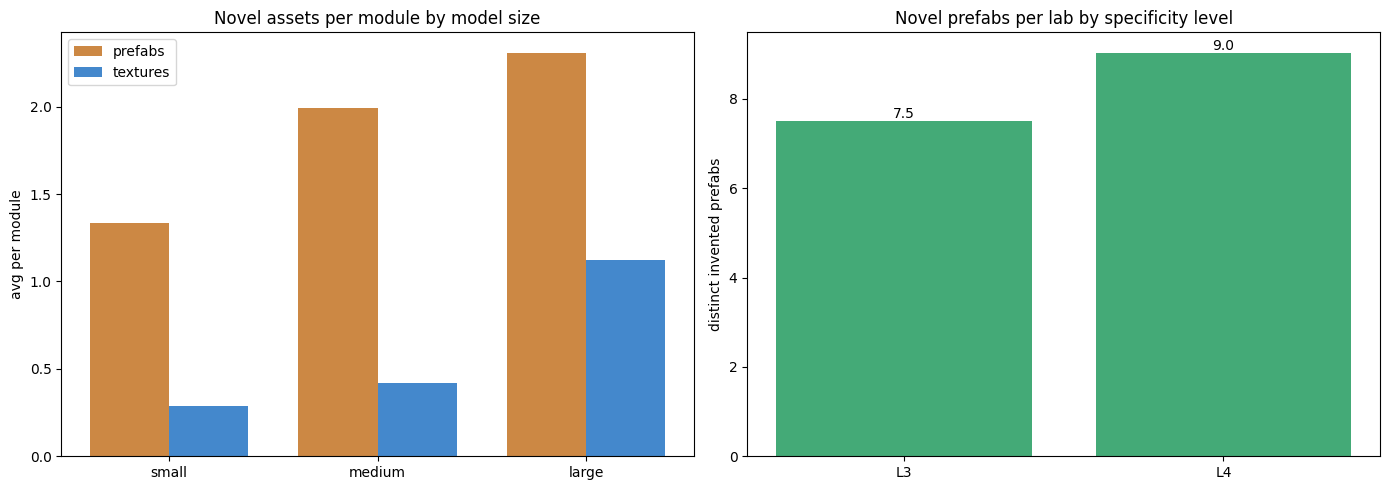

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Novel prefabs & textures per module by model size (json_lab only)
order = ['small', 'medium', 'large']
pm = FULL_JSON.groupby('size').novel_prefabs_per_module.mean().reindex(order)
tm = FULL_JSON.groupby('size').novel_textures_per_module.mean().reindex(order)
x = np.arange(len(order)); w = 0.38
axes[0].bar(x - w/2, pm.values, w, label='prefabs', color='#c84')
axes[0].bar(x + w/2, tm.values, w, label='textures', color='#48c')
axes[0].set_xticks(x); axes[0].set_xticklabels(order)
axes[0].set_title('Novel assets per module by model size')
axes[0].set_ylabel('avg per module'); axes[0].legend()

# Novel prefabs per lab by specificity level (json_lab only)
lv = ['L3', 'L4']
k = FULL_JSON.groupby('level').novel_prefabs.mean().reindex(lv)
axes[1].bar(lv, k.values, color='#4a7')
axes[1].set_title('Novel prefabs per lab by specificity level')
axes[1].set_ylabel('distinct invented prefabs')
for i, v in enumerate(k.values):
    axes[1].annotate(f'{v:.1f}', (i, v), ha='center', va='bottom')

plt.tight_layout(); plt.show()

## Failed runs

Failures live only in the `suite_results_*.json` sweeps (a successful run also writes a standalone metrics file; a failed one does not). They split cleanly into two kinds, keyed on whether the run actually reached the model and burned tokens (`had_usage`):

- **Billable failures** — `truncation (max_tokens)` and `schema validation` retries generated real output before failing, so they carry meaningful token / cost / time stats (and are often *more* expensive than a success, because instructor retried).
- **No-op failures** — `404 model-not-found` and config errors never reached the model: 0 tokens, $0, sub-second. They have no relevant statistics and are excluded from the cost/token aggregates below.

In [12]:
# Overview: how common is each failure mode, and is it billable?
ov = FAIL.groupby('fail_mode').agg(
    failed_runs=('model', 'size'),
    billable=('had_usage', 'sum'),
    total_tokens=('total_tokens', 'sum'),
    total_cost_usd=('cost_usd', 'sum'),
    avg_wall_s=('wall_s', 'mean'),
).round({'total_cost_usd': 2, 'avg_wall_s': 1}).sort_values('failed_runs', ascending=False)
print('Failure modes (the "common errors" breakdown):')
display(ov)
wasted = FAIL.cost_usd.sum(); spent = OK.cost_usd.sum()
print(f'Spend on failed runs: ${wasted:.2f}  ({wasted / (wasted + spent):.1%} of total ${wasted + spent:.2f}) — all from billable failures.')

Failure modes (the "common errors" breakdown):


,failed_runs,billable,total_tokens,total_cost_usd,avg_wall_s
fail_mode,,,,,
other,153,8,164942,1.38,8.4
schema validation,57,57,1572376,5.18,53.9


Spend on failed runs: $6.55  (17.2% of total $38.01) — all from billable failures.


### Billable failures — what they cost

Token/cost/time for the failures that actually did work, by model. These are the runs worth attention: real money spent on output that didn't validate or got truncated.

In [13]:
BILL = FAIL[FAIL.had_usage]
by_model = BILL.groupby('display_name').agg(
    failed_runs=('model', 'size'),
    total_tokens=('total_tokens', 'sum'),
    total_cost_usd=('cost_usd', 'sum'),
    avg_wall_s=('wall_s', 'mean'),
    avg_retries=('retries', 'mean'),
).round({'total_cost_usd': 3, 'avg_wall_s': 1, 'avg_retries': 1})
display(by_model.sort_values('total_cost_usd', ascending=False))
print('By level:')
display(BILL.groupby('level').agg(
    failed_runs=('model', 'size'),
    avg_tokens=('total_tokens', 'mean'),
    avg_cost_usd=('cost_usd', 'mean'),
    avg_wall_s=('wall_s', 'mean'),
).round(2))

,failed_runs,total_tokens,total_cost_usd,avg_wall_s,avg_retries
display_name,,,,,
Claude Sonnet 5,5,572012,3.229,174.9,5.0
GPT-5.5,3,98055,2.100,166.8,5.0
Claude Haiku 4.5,14,220869,0.616,44.5,3.0
Gemini 3.5 Flash,9,158798,0.427,47.2,3.0
Gemini 3.1 Flash Lite,17,197392,0.092,6.4,3.3
Gemini 2.5 Flash Lite,17,490192,0.089,75.5,4.4


By level:


,failed_runs,avg_tokens,avg_cost_usd,avg_wall_s
level,,,,
L3,33,25919.52,0.13,63.00
L4,32,27561.69,0.07,54.25


### No-op failures — no relevant statistics

Listed for completeness; these never billed. (`404` = deprecated/bad model id; `other` = a missing-argument config error.)

In [14]:
NOOP = FAIL[~FAIL.had_usage]
display(NOOP[['display_name', 'level', 'lab_name', 'fail_mode', 'total_tokens', 'cost_usd', 'wall_s']].reset_index(drop=True))

,display_name,level,lab_name,fail_mode,total_tokens,cost_usd,wall_s
0,Gemini 3.1 Pro,L1,apparent_retrograde_motion,other,0,0.0,0.36
1,Gemini 3.1 Pro,L1,dna_structure_and_replication,other,0,0.0,0.31
2,Gemini 3.1 Pro,L1,heart_anatomy_and_blood_flow,other,0,0.0,0.27
3,Gemini 3.1 Pro,L1,vectors_and_projectile_motion,other,0,0.0,0.27
4,Gemini 3.1 Pro,L1,vsepr_molecular_geometry,other,0,0.0,0.38
5,GPT-5.5,L3,heart_anatomy_and_blood_flow,other,0,0.0,5.76
6,GPT-5.5,L3,vectors_and_projectile_motion,other,0,0.0,5.22
7,GPT-5.5,L3,vsepr_molecular_geometry,other,0,0.0,5.09
8,GPT-5.4,L3,apparent_retrograde_motion,other,0,0.0,4.76
9,GPT-5.4,L3,dna_structure_and_replication,other,0,0.0,4.59


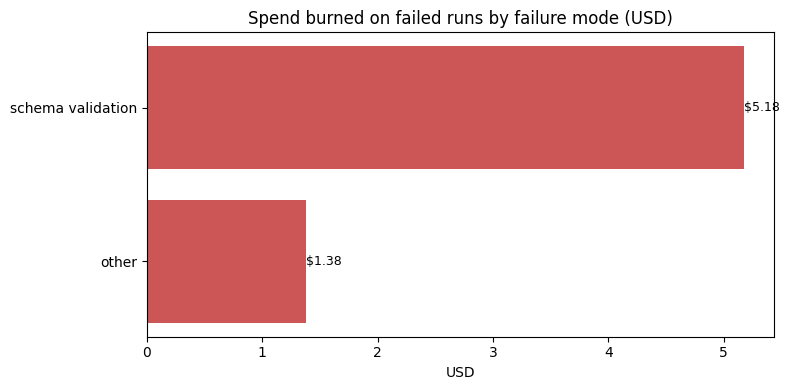

In [15]:
# Cost burned per failure mode (billable only).
fig, ax = plt.subplots(figsize=(8, 4))
fc = BILL.groupby('fail_mode').cost_usd.sum().sort_values()
ax.barh(fc.index, fc.values, color='#c55')
ax.set_title('Spend burned on failed runs by failure mode (USD)')
ax.set_xlabel('USD')
for i, v in enumerate(fc.values):
    ax.annotate(f'${v:.2f}', (v, i), va='center', fontsize=9)
plt.tight_layout(); plt.show()

## Charts

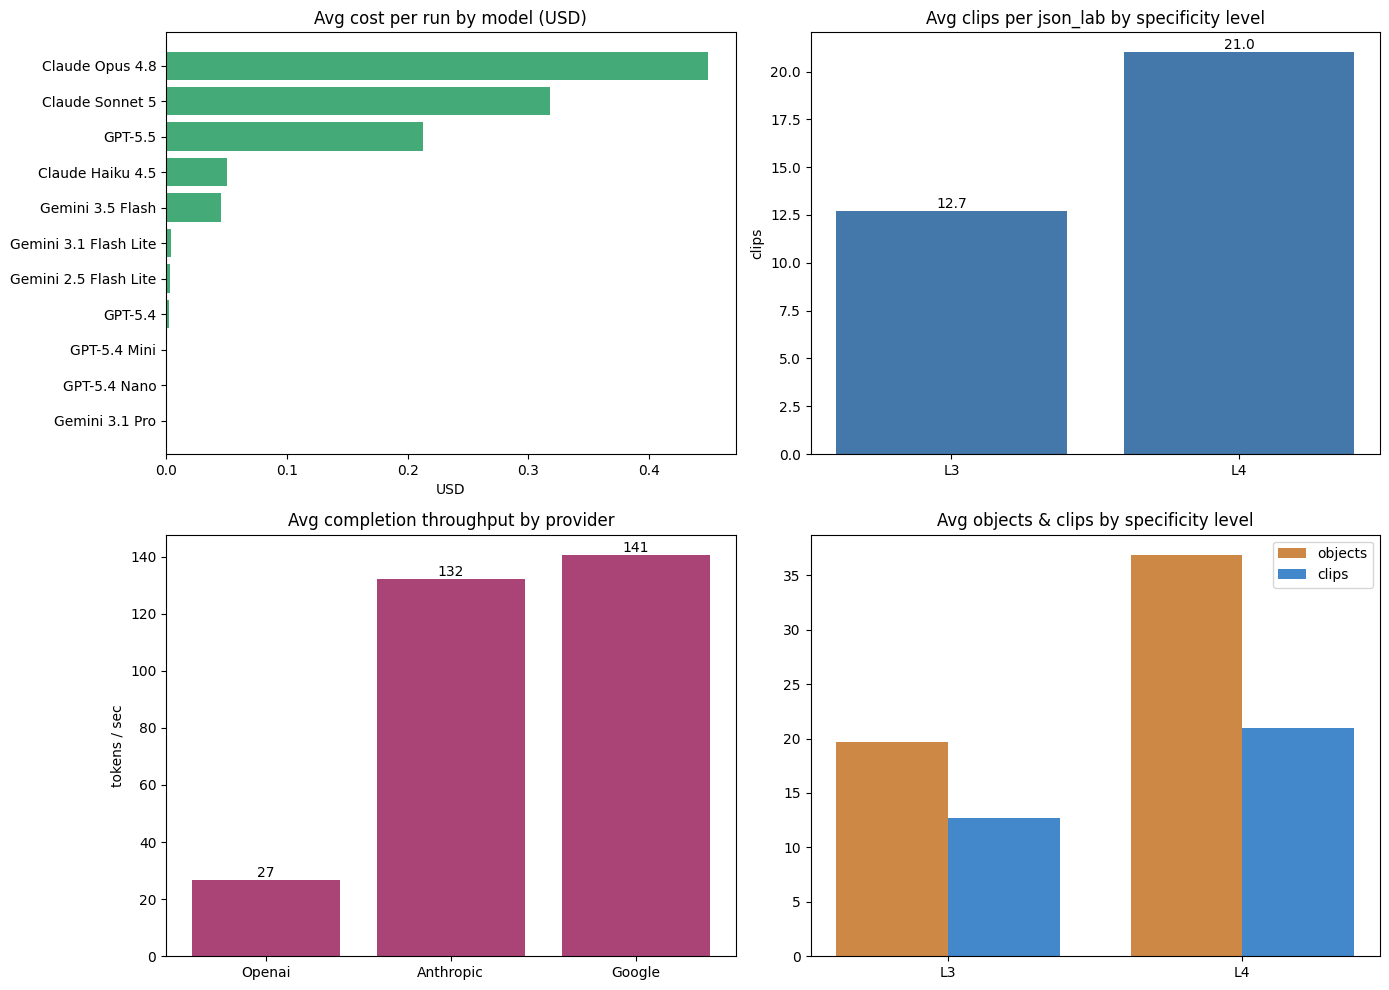

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Avg cost per run by model
c = df.groupby('display_name').cost_usd.mean().sort_values()
axes[0, 0].barh(c.index, c.values, color='#4a7')
axes[0, 0].set_title('Avg cost per run by model (USD)')
axes[0, 0].set_xlabel('USD')

# 2. Avg clips by level (json_lab, L3-L4)
k = FULL_JSON.groupby('level').num_clips.mean().reindex(['L3','L4'])
axes[0, 1].bar(k.index, k.values, color='#47a')
axes[0, 1].set_title('Avg clips per json_lab by specificity level')
axes[0, 1].set_ylabel('clips')
for i, v in enumerate(k.values):
    axes[0, 1].annotate(f'{v:.1f}', (i, v), ha='center', va='bottom')

# 3. Avg throughput by provider
s = df.groupby('provider').tokens_per_sec.mean().reindex(PROVIDERS)
axes[1, 0].bar([p.capitalize() for p in s.index], s.values, color='#a47')
axes[1, 0].set_title('Avg completion throughput by provider')
axes[1, 0].set_ylabel('tokens / sec')
for i, v in enumerate(s.values):
    axes[1, 0].annotate(f'{v:.0f}', (i, v), ha='center', va='bottom')

# 4. Avg objects vs clips by level (json_lab)
lv = ['L3', 'L4']
objs = FULL_JSON.groupby('level').num_objects.mean().reindex(lv)
clps = FULL_JSON.groupby('level').num_clips.mean().reindex(lv)
x = np.arange(len(lv)); w = 0.38
axes[1, 1].bar(x - w/2, objs.values, w, label='objects', color='#c84')
axes[1, 1].bar(x + w/2, clps.values, w, label='clips', color='#48c')
axes[1, 1].set_xticks(x); axes[1, 1].set_xticklabels(lv)
axes[1, 1].set_title('Avg objects & clips by specificity level')
axes[1, 1].legend()

plt.tight_layout(); plt.show()

## Notes

- Cost/token figures are the raw provider-reported `cost_usd` / `total_tokens`. Every spec runs free-decode, so there is no Gemini schema-token adjustment (the old `effective_*` columns were retired).
- Structural sections split by **spec_type**: json_lab shape (modules/clips/objects) uses `FULL_JSON`; ARLEM shape (things/places/actions/triggers/POIs) uses `FULL_ARLEM`. A row carries 0 for the columns that don't apply to its spec.
- Structural counts are over **successful** L3–L4 runs only; a model that failed a level contributes no row there.
- Failed-run stats use `had_usage` (`total_tokens > 0`) to separate billable failures from no-op ones; only billable failures enter the cost/token aggregates.
- `num_components` is the count of components created per lab ("new components made"); the per-type breakdown lives in the source metrics' `component_types` if a finer cut is needed.
- Novel-asset counts are computed by re-reading each saved `*_output.json` at load time (no re-running of the sweep); membership in the known moon-lab library is case-insensitive. The invented asset *names* aren't in the CSV but are available per-lab via `lab_metrics.analyze_assets(output_json)` (`novel_prefab_names` / `novel_texture_names`) for qualitative review.